In [1]:
!pip install git+https://github.com/huggingface/transformers.git
!pip install datasets
!pip install dill==0.3.5.1
!pip install humanfriendly
!pip install habanero  # Install the habanero package
!pip install doi2bib # https://pypi.org/project/doi2bib/
!pip install pybliometrics
!pip install torch transformers accelerate
# !pip install transformers
!pip install torch
!pip install tensorflow
!pip install sentence_transformers
!pip install bert-extractive-summarizer
!pip install spacy==2.0.12
!pip install cairocffi
!pip install summarizer
!pip install python-igraph

  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-qjx61y_3
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-qjx61y_3
  Resolved https://github.com/huggingface/transformers.git to commit a7d9d9493fcd62a65f0f73f4f0639cee1b90e721
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.9/842.9 kB 35.9 MB/s eta 0:00:00
  Created wheel for transformers: filename=transformers-5.18.0.dev0-py3-none-any.whl size=13562642 sha256=291b15523ca878e1819cbef99271fdc24de40b094b9f68b08debce5338e86e48
  Stored in directory: /tmp/pip-ephem-wheel-cache-ps8tzxpn/wheels/90/86/bb/8ad35b428289429952d8316d30f64abedae0ab2fcee0f4f46f
Successfully built transformers
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.29.0
    Uninstalling huggingface_

In [ ]:
import requests
import pandas as pd
import json
import re
# https://github.com/allenai/s2-folks/tree/main/examples/python
# Cosine similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import datetime
from datetime import datetime, date, time, timedelta
import http.client, urllib
import time
from time import strftime
from time import gmtime
from humanfriendly import format_timespan
from pybliometrics.scopus import CitationOverview
import requests
from habanero import Crossref
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import pybliometrics
drive.mount('/content/drive')
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/Forest_policy_review")  # set WD
import time
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import linkage
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from scipy.spatial.distance import squareform # Corrected import
from scipy.cluster.hierarchy import cut_tree, dendrogram, linkage #Import necessary functions
# from summarizer import Summarizer,TransformerSummarizer
from transformers import BartForConditionalGeneration, BartTokenizer
from collections import defaultdict
import zipfile
from habanero import Crossref
from collections import defaultdict
import pickle
from collections import defaultdict
from transformers import ModernBertForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments, DataCollatorWithPadding
from datasets import load_dataset
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import random
from datasets import Dataset

import torch
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import random
from transformers import AutoTokenizer, ModernBertForSequenceClassification # Assuming you are using ModernBert
from datasets import load_dataset
import nltk
from nltk.corpus import stopwords
import time
import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
######## SAMPLING SECTION
#### This section is to sample what papers are in the scope of FPE
# the initial input are JSON files per paper, separately for 'cited by' and 'citations part'. Both have metadata. This is a million files in total
# These have been compiled into two files - df_info_full and edgelist_cut_draft / edgelist_sampling_frame_320k objects
# df_info_full is a metadata file for all the papers
# edgelist_sampling_frame_320k is an edgelist. First is the paper that cites, and then cited paper - identified by title, DOI and EID
# Both files are entire snowball sampling frame
# Code below shows how to sample the FPE. Further explanation is in the paper

In [ ]:
# Load the metadata file
df_info_full = pd.read_parquet('df_info_full.parquet')
# Load the edgelist - sampling frame
edgelist_sampling_frame_320k = pd.read_parquet('edgelist_cut_draft.parquet')

In [ ]:
# Make graph object
edgelist_all = edgelist_sampling_frame_320k[['source_doi','target_doi']]

# Drop rows where source_doi or target_doi are null, drop duplicates
edgelist_all = edgelist_all.dropna(subset=['source_doi', 'target_doi'])
edgelist_all = edgelist_all.reset_index(drop=True)
edgelist_all.drop_duplicates(inplace=True)

edgelist_all['weight'] = 1 # add weight
Row_list =[]
# Iterate over each row
for index, rows in edgelist_all.iterrows():
    # Create list for the current row
    my_list =[rows.source_doi, rows.target_doi, rows.weight]
    # append the list to the final list
    Row_list.append(my_list)
graph = nx.DiGraph()
graph.add_weighted_edges_from(Row_list)


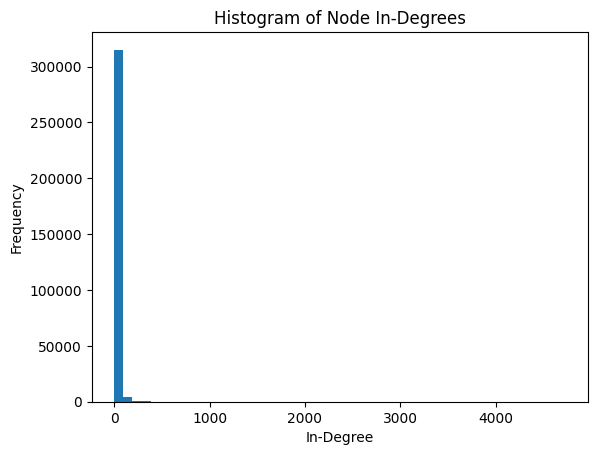

In [ ]:
indegrees = pd.Series([degree for node, degree in graph.in_degree()])
plt.hist(indegrees, bins=50)
plt.title('Histogram of Node In-Degrees')
plt.xlabel('In-Degree')
plt.ylabel('Frequency')
plt.show()

In [ ]:
outdegrees = pd.Series([degree for node, degree in graph.out_degree()])
total_nodes = len(outdegrees)

print('Share of nodes with specific outdegrees:')
for i in range(1, 15):
    count = (outdegrees == i).sum()
    share = (count / total_nodes) * 100
    print(f'Outdegree {i}: {share:.2f}%')

Share of nodes with specific outdegrees:
Outdegree 1: 8.51%
Outdegree 2: 8.18%
Outdegree 3: 7.45%
Outdegree 4: 6.68%
Outdegree 5: 6.05%
Outdegree 6: 5.44%
Outdegree 7: 4.94%
Outdegree 8: 4.51%
Outdegree 9: 4.08%
Outdegree 10: 3.71%
Outdegree 11: 3.42%
Outdegree 12: 3.01%
Outdegree 13: 2.77%
Outdegree 14: 2.52%


In [ ]:
# Make a list of DOIs have outdegree of 1 - for LLM TRAINING
DOIs_out_of_sample = [node for node, outdegree in dict(graph.out_degree()).items() if outdegree == 1]
print(f"Number of nodes with outdegree 1: {len(DOIs_out_of_sample)}")

Number of nodes with outdegree 1: 27277


In [ ]:
# make a list for in the sameple  - V1
# top 5% indegree + all FPE - for LLM TRAINING

# List 1: Nodes containing 'forpol'
nodes_with_forpol = [node for node in graph.nodes() if 'forpol' in str(node).lower()]

# List 2: Nodes with 5% highest indegree
indegree_dict = dict(graph.in_degree())

# Sort nodes by indegree in descending order
sorted_nodes_by_indegree = sorted(indegree_dict.items(), key=lambda item: item[1], reverse=True)

# Calculate the number of nodes for the top 5%
num_top_5_percent = int(len(sorted_nodes_by_indegree) * 0.05)

# Get the nodes corresponding to the top 5% indegrees
nodes_top_5_percent_indegree = [node for node, _ in sorted_nodes_by_indegree[:num_top_5_percent]]

# Combine the two lists and get unique nodes
combined_nodes = list(set(nodes_with_forpol + nodes_top_5_percent_indegree))

#remove duplicates
DOIs_in_sample = list(set(combined_nodes))
print(f"Number of nodes containing 'forpol': {len(nodes_with_forpol)}")
print(f"Number of nodes in top 5% by indegree: {len(nodes_top_5_percent_indegree)}")
print(f"Number of unique nodes in the combined list: {len(DOIs_in_sample)}")
print("First 10 combined nodes:")
for node in DOIs_in_sample[:10]:
    print(node)

Number of nodes containing 'forpol': 2614
Number of nodes in top 5% by indegree: 16030
Number of unique nodes in the combined list: 18294
First 10 combined nodes:
10.1016/j.jenvman.2017.02.012
10.1016/j.forpol.2023.103028
10.1016/j.tourman.2017.04.010
10.5751/ES-05063-170330
10.1016/j.ecolecon.2012.08.019
10.1111/cobi.12784
10.1016/j.agsy.2005.09.009
10.1016/j.forpol.2023.102956
10.1002/ldr.3583
10.1038/ncomms7936


In [ ]:
# Option 2 - in-sample is based on top 5% eigenvector centrality

In [ ]:
# make a list for in the sameple  - V2
# top 5% eigenvector centrality + all FPE - for LLM TRAINING

# List 1: Nodes containing 'forpol' (re-using the existing definition)
nodes_with_forpol = [node for node in graph.nodes() if 'forpol' in str(node).lower()]

# Calculate eigenvector centrality
eigenvector_centrality = nx.eigenvector_centrality(graph, max_iter=1000, tol=1e-06)

# Sort nodes by eigenvector centrality in descending order
sorted_nodes_by_eigenvector = sorted(eigenvector_centrality.items(), key=lambda item: item[1], reverse=True)

# Calculate the number of nodes for the top 5%
num_top_5_percent_eigenvector = int(len(sorted_nodes_by_eigenvector) * 0.05)

# Get the nodes corresponding to the top 5% eigenvector centrality
nodes_top_5_percent_eigenvector = [node for node, _ in sorted_nodes_by_eigenvector[:num_top_5_percent_eigenvector]]

# Combine the two lists and get unique nodes
combined_nodes_new_method = list(set(nodes_with_forpol + nodes_top_5_percent_eigenvector))

# Assign to DOIs_in_sample
DOIs_in_sample = list(set(combined_nodes_new_method))

print(f"Number of nodes containing 'forpol': {len(nodes_with_forpol)}")
print(f"Number of nodes in top 5% by eigenvector centrality: {len(nodes_top_5_percent_eigenvector)}")
print(f"Number of unique nodes in the combined list (new method): {len(DOIs_in_sample)}")
print("First 10 combined nodes (new method):")
for node in DOIs_in_sample[:10]:
    print(node)


Number of nodes containing 'forpol': 2614
Number of nodes in top 5% by eigenvector centrality: 16030
Number of unique nodes in the combined list (new method): 18306
First 10 combined nodes (new method):
10.5751/ES-03520-150320
10.1016/j.forpol.2023.103028
10.5751/ES-05063-170330
10.1016/j.ecolecon.2012.08.019
10.1016/j.agsy.2005.09.009
10.1016/j.forpol.2023.102956
10.1093/jof/109.1.50
10.1111/j.1435-5957.2005.00002.x
10.1038/ncomms7936
10.1016/j.forpol.2011.08.011


In [ ]:
# remove papers that have 4 or less references
nodes_to_remove = [node for node, outdegree in dict(graph.out_degree()).items() if outdegree <= 4]
graph.remove_nodes_from(nodes_to_remove)
num_nodes = len(graph.nodes())
num_edges = len(graph.edges())
print(f"Number of nodes in the graph: {num_nodes}")
print(f"Number of edges in the graph: {num_edges}")

Number of nodes in the graph: 208805
Number of edges in the graph: 2411521


In [ ]:
# Make louvain_communities
community = nx.community.louvain_communities(graph, seed=123)
community = [list(sub_community) for sub_community in community]

In [ ]:
df_info_BERT_classification = pd.read_csv('df_info_BERT_classification.csv')

In [ ]:
import networkx as nx

# Recreate the graph from edgelist_sampling_frame_320k to ensure it's unfiltered
# This copies the graph creation logic from cell C3d4IgZNDQwd
edgelist_all_unfiltered = edgelist_sampling_frame_320k[['source_doi','target_doi']]
edgelist_all_unfiltered = edgelist_all_unfiltered.dropna(subset=['source_doi', 'target_doi'])
edgelist_all_unfiltered = edgelist_all_unfiltered.reset_index(drop=True)
edgelist_all_unfiltered.drop_duplicates(inplace=True)
edgelist_all_unfiltered['weight'] = 1
Row_list_unfiltered =[]
for index, rows in edgelist_all_unfiltered.iterrows():
    my_list =[rows.source_doi, rows.target_doi, rows.weight]
    Row_list_unfiltered.append(my_list)
graph_for_community_detection = nx.DiGraph()
graph_for_community_detection.add_weighted_edges_from(Row_list_unfiltered)

print(f"Recreated graph with {len(graph_for_community_detection.nodes())} nodes and {len(graph_for_community_detection.edges())} edges for community detection.")

Recreated graph with 320605 nodes and 3622274 edges for community detection.


In [ ]:
# Prepare doi_to_sample_map for efficient lookup
doi_to_sample_map = df_info_BERT_classification.set_index('doi')['sample'].to_dict()

all_communities_data = []
community_counter = 0 # To assign unique IDs

def process_community(community_members_list, level, parent_id):
    global all_communities_data
    global community_counter

    if not community_members_list:
        return

    current_subgraph = graph_for_community_detection.subgraph(community_members_list)

    # Step 1: If the subgraph has fewer than 2 nodes, or is already small enough, record it and stop recursion.
    if len(current_subgraph.nodes()) <= 100:
        community_size = len(current_subgraph.nodes())
        # Calculate metrics for this community (most cited, top 10, share_in_sample)
        indegree_dict = dict(current_subgraph.in_degree(current_subgraph.nodes()))
        sorted_members_by_indegree = sorted(indegree_dict.items(), key=lambda item: item[1], reverse=True)
        most_cited_doi = sorted_members_by_indegree[0][0] if sorted_members_by_indegree else None
        top_10_cited_dois = [member[0] for member in sorted_members_by_indegree[:10]]
        count_in_sample = sum(doi_to_sample_map.get(doi, 0) for doi in current_subgraph.nodes())
        share_in_sample = count_in_sample / community_size if community_size > 0 else 0

        all_communities_data.append({
            'community_id': f"{parent_id}-{community_counter}", # Unique ID for this leaf node
            'level': level,
            'size': community_size,
            'most_cited_doi': most_cited_doi,
            'top_10_cited_dois': ', '.join(top_10_cited_dois),
            'share_in_sample': share_in_sample,
            'all_members_dois': ', '.join(list(current_subgraph.nodes()))
        })
        community_counter += 1
        return # This community is processed, stop recursion.

    # Step 2: If the subgraph is large (>100 nodes) but not weakly connected,
    # break it into its weakly connected components and process each one recursively.
    if not nx.is_weakly_connected(current_subgraph):
        for k, component_nodes in enumerate(nx.weakly_connected_components(current_subgraph)):
            component_list = list(component_nodes)
            if len(component_list) > 0:
                process_community(component_list, level, f"{parent_id}-WCC-{k}")
        return # All components of this (disconnected) graph have been processed.

    # Step 3: If we reach here, the current_subgraph is weakly connected AND larger than 100 nodes.
    # Apply Louvain community detection.
    sub_communities = nx.community.louvain_communities(current_subgraph, seed=123)
    sub_communities = [list(c) for c in sub_communities] # Convert frozensets to lists

    # Edge case: Louvain returns only one sub-community, meaning it couldn't split it further.
    # Treat this large, indivisible community as a leaf node and record it.
    if len(sub_communities) == 1 and set(sub_communities[0]) == set(community_members_list):
        community_size = len(community_members_list)
        indegree_dict = dict(current_subgraph.in_degree(community_members_list))
        sorted_members_by_indegree = sorted(indegree_dict.items(), key=lambda item: item[1], reverse=True)
        most_cited_doi = sorted_members_by_indegree[0][0] if sorted_members_by_indegree else None
        top_10_cited_dois = [member[0] for member in sorted_members_by_indegree[:10]]
        count_in_sample = sum(doi_to_sample_map.get(doi, 0) for doi in community_members_list)
        share_in_sample = count_in_sample / community_size if community_size > 0 else 0

        all_communities_data.append({
            'community_id': f"{parent_id}-leaf-{community_counter}", # Unique ID for this indivisible leaf node
            'level': level,
            'size': community_size,
            'most_cited_doi': most_cited_doi,
            'top_10_cited_dois': ', '.join(top_10_cited_dois),
            'share_in_sample': share_in_sample,
            'all_members_dois': ', '.join(community_members_list)
        })
        community_counter += 1
        return # Stop processing this branch.

    # Step 4: If Louvain successfully split the community, recursively process each sub-community.
    for j, current_sub_community_members in enumerate(sub_communities):
        process_community(current_sub_community_members, level + 1, f"{parent_id}-{j}")

# Initial call with all nodes from the unfiltered graph
initial_community_members = list(graph_for_community_detection.nodes())
print(f"Starting iterative community detection on {len(initial_community_members)} nodes.")
# Reset all_communities_data and community_counter before the initial call
all_communities_data = []
community_counter = 0
process_community(initial_community_members, 0, "C")

df_recursive_communities = pd.DataFrame(all_communities_data)

# Save to Excel
excel_file_path = 'df_recursive_communities_analysis.xlsx'
df_recursive_communities.to_excel(excel_file_path, index=False)

print(f"Generated {len(df_recursive_communities)} communities/sub-communities. Saved to '{excel_file_path}'.")
display(df_recursive_communities.head())

Starting iterative community detection on 320605 nodes.
Generated 17462 communities/sub-communities. Saved to 'df_recursive_communities_analysis.xlsx'.


,community_id,level,size,most_cited_doi,top_10_cited_dois,share_in_sample,all_members_dois
0,C-WCC-0-0-WCC-0-0-0,2,41,10.1016/j.jnc.2017.11.005,"10.1016/j.jnc.2017.11.005, 10.1017/S1466046613...",0.292683,"10.1007/978-3-319-32476-0_11, 10.1016/j.jnc.20..."
1,C-WCC-0-0-WCC-0-1-0-1,3,27,10.1016/j.eswa.2018.12.001,"10.1016/j.eswa.2018.12.001, 10.1016/j.resourpo...",0.074074,"10.3390/su9101705, 10.1016/j.exis.2015.11.007,..."
2,C-WCC-0-0-WCC-0-1-1-2,3,15,10.3390/su8101058,"10.3390/su8101058, 10.1016/j.scs.2020.102211, ...",0.000000,"10.1007/s10668-022-02364-w, 10.1016/j.seps.202..."
3,C-WCC-0-0-WCC-0-1-2-3,3,30,10.1016/j.mineng.2012.01.006,"10.1016/j.mineng.2012.01.006, 10.1016/j.jclepr...",0.100000,"10.24425/gsm.2020.132563, 10.1016/j.jenvman.20..."
4,C-WCC-0-0-WCC-0-1-3-4,3,22,10.1016/j.jclepro.2019.05.029,"10.1016/j.jclepro.2019.05.029, 10.1016/j.jclep...",0.181818,"10.4000/tem.4440, 10.1016/j.jclepro.2019.11974..."


In [ ]:
df_recursive_communities_analysis = pd.read_excel('df_recursive_communities_analysis.xlsx')

In [ ]:
# 1. Filter df_recursive_communities_analysis for 'Manual_sampling' == 1
manual_sampled_communities = df_recursive_communities_analysis[df_recursive_communities_analysis['Manual_sampling'] == 1]

# 2. Extract all unique DOIs from the 'all_members_dois' column
all_dois_from_manual_sample = set()
for dois_str in manual_sampled_communities['all_members_dois']:
    # Split the string by ', ' and add to the set
    if isinstance(dois_str, str):
        all_dois_from_manual_sample.update(doi.strip() for doi in dois_str.split(', '))

# Ensure the graph (graph_for_community_detection) is the unfiltered one
# This ensures we are working with the complete graph before filtering based on the manual sample
edgelist_all_unfiltered = edgelist_sampling_frame_320k[['source_doi','target_doi']]
edgelist_all_unfiltered = edgelist_all_unfiltered.dropna(subset=['source_doi', 'target_doi'])
edgelist_all_unfiltered = edgelist_all_unfiltered.reset_index(drop=True)
edgelist_all_unfiltered.drop_duplicates(inplace=True)
edgelist_all_unfiltered['weight'] = 1
Row_list_unfiltered =[]
for index, rows in edgelist_all_unfiltered.iterrows():
    my_list =[rows.source_doi, rows.target_doi, rows.weight]
    Row_list_unfiltered.append(my_list)
graph_unfiltered = nx.DiGraph()
graph_unfiltered.add_weighted_edges_from(Row_list_unfiltered)

# 3. Create a subgraph containing only the extracted DOIs
# Filter nodes that are actually present in the original graph
nodes_to_include = [node for node in all_dois_from_manual_sample if node in graph_unfiltered.nodes()]

# Create the new graph (subgraph)
graph_manual_sample_filtered = graph_unfiltered.subgraph(nodes_to_include)

print(f"Original graph had {len(graph_unfiltered.nodes())} nodes and {len(graph_unfiltered.edges())} edges.")
print(f"Filtered graph (graph_manual_sample_filtered) has {len(graph_manual_sample_filtered.nodes())} nodes and {len(graph_manual_sample_filtered.edges())} edges.")

Original graph had 320605 nodes and 3622274 edges.
Filtered graph (graph_manual_sample_filtered) has 97437 nodes and 1167378 edges.


In [ ]:
# Make louvain_communities on the filtered graph
community_manual_sample_filtered = nx.community.louvain_communities(graph_manual_sample_filtered, seed=123)
community_manual_sample_filtered = [list(sub_community) for sub_community in community_manual_sample_filtered]

print(f"Found {len(community_manual_sample_filtered)} communities in graph_manual_sample_filtered.")

Found 436 communities in graph_manual_sample_filtered.


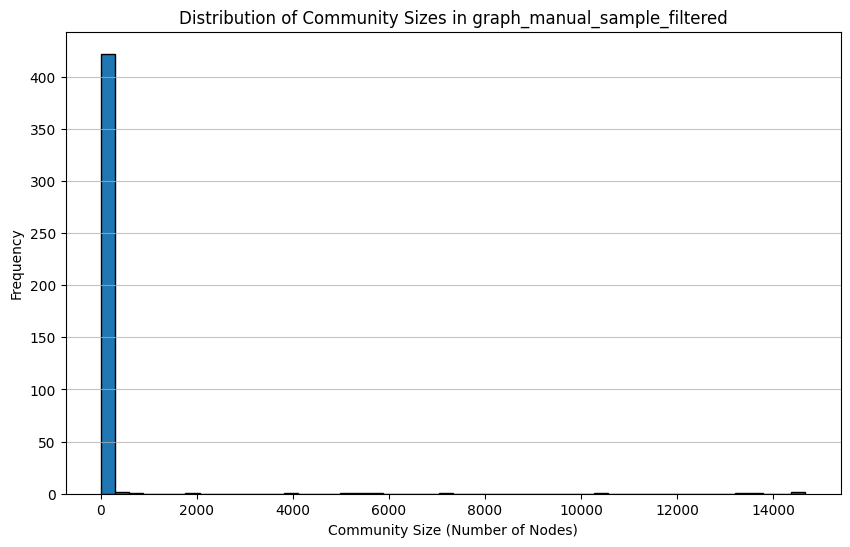

Descriptive statistics for community sizes:
count      436.000000
mean       223.479358
std       1538.274164
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max      14676.000000
dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract community sizes
community_sizes = [len(community) for community in community_manual_sample_filtered]

# Create a pandas Series for easier analysis (optional, but good practice)
community_sizes_series = pd.Series(community_sizes)

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(community_sizes_series, bins=50, edgecolor='black')
plt.title('Distribution of Community Sizes in graph_manual_sample_filtered')
plt.xlabel('Community Size (Number of Nodes)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Descriptive statistics for community sizes:")
print(community_sizes_series.describe())

In [ ]:
total_members_in_large_communities = 0
for community in community_manual_sample_filtered:
    if len(community) > 5:
        total_members_in_large_communities += len(community)

print(f"Total members in communities larger than 2: {total_members_in_large_communities}")

Total members in communities larger than 2: 97012


In [ ]:
num_communities_larger_than_1 = (community_sizes_series > 2).sum()
print(f"Number of communities larger than 1: {num_communities_larger_than_1}")

Number of communities larger than 1: 16


In [ ]:
# Initialize an empty list to store the data for the new DataFrame
community_analysis_data = []

# Prepare df_info_full for efficient abstract lookup
# Ensure 'abstract' column is string type and fill NaN for concatenation later
df_info_full['abstract'] = df_info_full['abstract'].fillna('').astype(str)

# Create df_info_full_unique_doi to ensure a unique index, handling cases where df_info_full might have duplicate DOIs
df_info_full_unique_doi = df_info_full.drop_duplicates(subset=['doi'])

# Use df_info_full_unique_doi (created in a previous cell) to ensure a unique index
df_info_full_indexed = df_info_full_unique_doi.set_index('doi')

# Iterate through each community in community_manual_sample_filtered
for i, community_nodes in enumerate(community_manual_sample_filtered):
    # Ensure community_nodes is a list of nodes present in the graph
    valid_nodes = [node for node in community_nodes if node in graph_manual_sample_filtered.nodes()]

    if not valid_nodes:
        continue # Skip empty communities

    # Create a subgraph for the current community
    subgraph = graph_manual_sample_filtered.subgraph(valid_nodes)

    # Calculate in-degrees within this subgraph
    in_degrees = dict(subgraph.in_degree())

    # Sort nodes by in-degree in descending order
    sorted_papers_by_indegree = sorted(in_degrees.items(), key=lambda item: item[1], reverse=True)

    # Get the DOI of the most cited paper (highest in-degree)
    most_cited_doi = sorted_papers_by_indegree[0][0] if sorted_papers_by_indegree else None

    # Select the top 100 papers by in-degree (or fewer if the community is smaller)
    top_100_dois = [item[0] for item in sorted_papers_by_indegree[:100]]

    abstracts_list = []
    for doi in top_100_dois:
        if doi in df_info_full_indexed.index:
            # Retrieve the abstract, which should now be a scalar string due to unique index
            abstracts_list.append(df_info_full_indexed.loc[doi, 'abstract'])
        else:
            abstracts_list.append('') # Add empty string if abstract not found

    # Concatenate abstracts, handling potential empty strings
    concatenated_abstracts = ' XXX '.join([a for a in abstracts_list if a]) # Filter out empty abstracts before joining

    # Append data for the current community
    community_analysis_data.append({
        'community_id': f'community_{i}', # Unique ID for the community
        'most_cited_paper_doi': most_cited_doi,
        'size': len(valid_nodes), # Add the size of the community
        'top_100_abstracts': concatenated_abstracts,
        'member_DOIs': ', '.join(valid_nodes) # Add the new column here
    })

# Create the final DataFrame
df_community_insights = pd.DataFrame(community_analysis_data)

print("DataFrame 'df_community_insights' created successfully.")
display(df_community_insights.head())

DataFrame 'df_community_insights' created successfully.


,community_id,most_cited_paper_doi,size,top_100_abstracts,member_DOIs
0,community_0,10.1017/s0376892900024322,1,,10.1017/s0376892900024322
1,community_1,10.1007/978-3-319-60714-6_8,1,This chapter proposes a network-based framewor...,10.1007/978-3-319-60714-6_8
2,community_2,10.1016/0306-9192(89)90081-X,1,,10.1016/0306-9192(89)90081-X
3,community_3,10.1177/02666669251314853,1,This article explores power dynamics within pa...,10.1177/02666669251314853
4,community_4,10.1016/0006-3207(72)90163-2,1,,10.1016/0006-3207(72)90163-2


In [ ]:
df_community_insights.to_csv('df_community_insights.csv')

In [ ]:
# Now here to filter the sampling frame to FPE

In [ ]:
# Load the metadata file
df_info_full = pd.read_parquet('df_info_full.parquet')
# Load the edgelist - sampling frame
edgelist_sampling_frame_320k = pd.read_parquet('edgelist_cut_draft.parquet')
# Load communities
df_community_insights_summarized = pd.read_csv('df_community_insights_summarized.csv')

In [ ]:
# Make graph object
edgelist_all = edgelist_sampling_frame_320k[['source_doi','target_doi']]

# Drop rows where source_doi or target_doi are null, drop duplicates
edgelist_all = edgelist_all.dropna(subset=['source_doi', 'target_doi'])
edgelist_all = edgelist_all.reset_index(drop=True)
edgelist_all.drop_duplicates(inplace=True)

edgelist_all['weight'] = 1 # add weight
Row_list =[]
# Iterate over each row
for index, rows in edgelist_all.iterrows():
    # Create list for the current row
    my_list =[rows.source_doi, rows.target_doi, rows.weight]
    # append the list to the final list
    Row_list.append(my_list)
graph = nx.DiGraph()
graph.add_weighted_edges_from(Row_list)

In [ ]:
# Filter the whole network just to FPE, and add communities with their descriptions

# 1. Extract all DOIs to be kept from df_community_insights_summarized
all_keep_dois = set()
for dois_str in df_community_insights_summarized['member_DOIs']:
    if isinstance(dois_str, str): # Ensure it's a string
        all_keep_dois.update(doi.strip() for doi in dois_str.split(', '))

# 2. Identify DOIs to exclude from specific communities
communities_to_exclude_ids = ['community_90', 'community_123', 'community_183', 'community_229', 'community_329', 'community_414'] # These are out of the scope .... based on manual check
dois_to_exclude = set()
for community_id in communities_to_exclude_ids:
    excluded_community_row = df_community_insights_summarized[df_community_insights_summarized['community_id'] == community_id]
    if not excluded_community_row.empty:
        dois_str_to_exclude = excluded_community_row.iloc[0]['member_DOIs']
        if isinstance(dois_str_to_exclude, str):
            dois_to_exclude.update(doi.strip() for doi in dois_str_to_exclude.split(', '))

# Add the user-specified DOIs to the exclusion list
user_specified_dois_to_exclude = "10.1016/S0140-6736(02)94687-8; 10.1093/nq/s5-X.248.251; 10.1093/nq/s6-iv.104.507b; 10.1111/j.1365-2311.1883.tb02945.x; 10.1007/BF02949548; 10.1088/1478-7814/19/1/304; 10.1007/BF01865034; 10.1126/science.35.906.740; 10.1039/AN923480490b; 10.1002/sce.3730100407; 10.1080/11035893509444917; 10.1126/science.1244693; 10.1016/S0921-8009(02)00089-7; 10.1016/j.ecolecon.2008.03.011"
dois_to_exclude.update(doi.strip() for doi in user_specified_dois_to_exclude.split(';') if doi.strip())


# If running this cell independently, ensure graph_unfiltered is defined:
edgelist_all_unfiltered = edgelist_sampling_frame_320k[['source_doi','target_doi']]
edgelist_all_unfiltered = edgelist_all_unfiltered.dropna(subset=['source_doi', 'target_doi'])
edgelist_all_unfiltered = edgelist_all_unfiltered.reset_index(drop=True)
edgelist_all_unfiltered.drop_duplicates(inplace=True)
edgelist_all_unfiltered['weight'] = 1
Row_list_unfiltered =[]
for index, rows in edgelist_all_unfiltered.iterrows():
    my_list =[rows.source_doi, rows.target_doi, rows.weight]
    Row_list_unfiltered.append(my_list)
graph_unfiltered = nx.DiGraph()
graph_unfiltered.add_weighted_edges_from(Row_list_unfiltered)


# 3. Determine the final set of nodes to include
# Filter all_keep_dois to ensure they are present in graph_unfiltered
valid_keep_dois_in_graph = {doi for doi in all_keep_dois if doi in graph_unfiltered.nodes()}
valid_exclude_dois_in_graph = {doi for doi in dois_to_exclude if doi in graph_unfiltered.nodes()}

# Calculate the final set of nodes by removing excluded ones from the kept ones
final_nodes_for_graph = valid_keep_dois_in_graph - valid_exclude_dois_in_graph

# 4. Create the filtered graph
graph_filtered_by_communities = graph_unfiltered.subgraph(final_nodes_for_graph).copy()

print(f"Original unfiltered graph nodes: {len(graph_unfiltered.nodes())}")
print(f"Nodes to keep from communities: {len(all_keep_dois)}")
print(f"Nodes to exclude from specified communities: {len(dois_to_exclude)}")
print(f"Final filtered graph has {len(graph_filtered_by_communities.nodes())} nodes and {len(graph_filtered_by_communities.edges())} edges.")

Original unfiltered graph nodes: 320605
Nodes to keep from communities: 97437
Nodes to exclude from specified communities: 20436
Final filtered graph has 77001 nodes and 891406 edges.


In [ ]:
# Assign communities

# Prepare a dictionary to store node-to-community attribute mapping
node_community_attributes = {}

# Define the label for small, ungrouped communities
ungrouped_community_label = '99-ungrouped'

# Create a set to store DOIs for small communities to group them later
small_community_dois = set()

# Iterate through each community in the summarized DataFrame
for index, row in df_community_insights_summarized.iterrows():
    community_id = row['community_id']
    community_size = row['size']
    member_dois_str = str(row['member_DOIs']) # Ensure it's a string

    # Split DOIs string into a list and clean up potential extra spaces
    member_dois = [doi.strip() for doi in member_dois_str.split(', ') if doi.strip()]

    if community_size > 10:
        # Use short_title_llm as the attribute, handling potential NaN
        attribute_value = str(row['short_title_llm']) if pd.notna(row['short_title_llm']) else f"Community_{community_id}"
        for doi in member_dois:
            # Only add if the DOI actually exists in the graph
            if doi in graph_filtered_by_communities.nodes():
                node_community_attributes[doi] = attribute_value
    else:
        # Collect DOIs for small communities
        for doi in member_dois:
            if doi in graph_filtered_by_communities.nodes():
                small_community_dois.add(doi)

# Assign the ungrouped label to all collected small community DOIs
for doi in small_community_dois:
    node_community_attributes[doi] = ungrouped_community_label

# Add the community attribute to the nodes in the graph
# Ensure all nodes in the graph have an attribute; assign a default if not found
for node in graph_filtered_by_communities.nodes():
    if node in node_community_attributes:
        graph_filtered_by_communities.nodes[node]['community_affiliation'] = node_community_attributes[node]
    else:
        # This handles any nodes that might be in the graph but weren't in df_community_insights_summarized
        # (e.g., if df_community_insights_summarized was a subset of the graph nodes)
        graph_filtered_by_communities.nodes[node]['community_affiliation'] = 'unassigned'

print(f"Community affiliations added to {len(node_community_attributes)} nodes in 'graph_filtered_by_communities'.")
print(f"Example nodes with their new 'community_affiliation' attribute:")
# Display a few examples
example_nodes = list(graph_filtered_by_communities.nodes())[:5]
for node in example_nodes:
    print(f"Node: {node}, Community: {graph_filtered_by_communities.nodes[node]['community_affiliation']}")


In [ ]:
# Count unique communities
unique_communities = set()
for node in graph_filtered_by_communities.nodes():
    if 'community_affiliation' in graph_filtered_by_communities.nodes[node]:
        unique_communities.add(graph_filtered_by_communities.nodes[node]['community_affiliation'])

print(f"The number of unique communities in graph_filtered_by_communities is: {len(unique_communities)}")

The number of unique communities in graph_filtered_by_communities is: 13


In [ ]:
# Export the graph_filtered_by_communities as a GEXF file
# It already contains the 'community_affiliation' attribute from cell IUbXwEYTmrYk
output_gexf_path = 'graph_filtered_by_communities_with_affiliations.gexf'
nx.write_gexf(graph_filtered_by_communities, output_gexf_path)

print(f"Graph exported to '{output_gexf_path}' with community affiliation attributes.")

Graph exported to 'graph_filtered_by_communities_with_affiliations.gexf' with community affiliation attributes.


Legend saved to 'community_legend.pdf'.


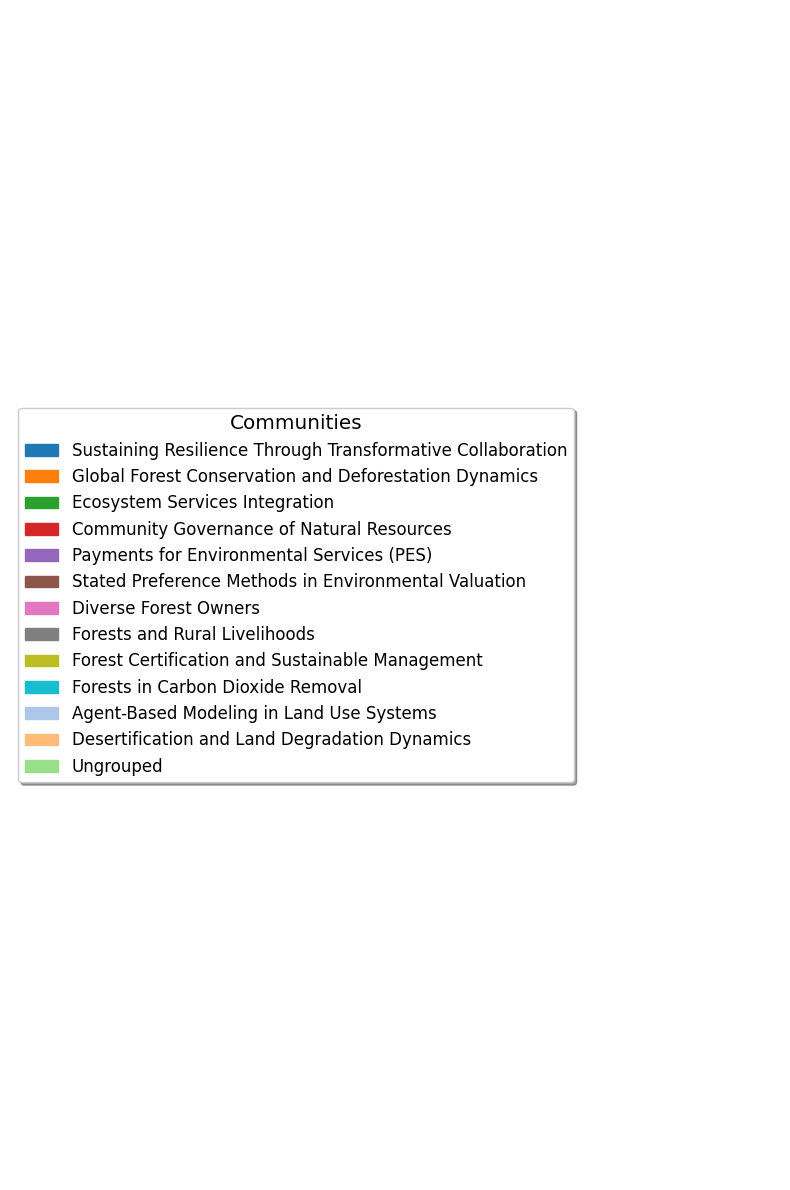

In [ ]:
# The graph is too big to vizualize with igraph or networkx. I've then just made a legend here
# All the sub-graphs are explorted and the vizualized in GEPHI

import matplotlib.patches as mpatches

# 1. Extract community sizes and labels
community_sizes = {}
for node in graph_filtered_by_communities.nodes():
    affiliation = graph_filtered_by_communities.nodes[node].get('community_affiliation', 'unassigned')
    community_sizes[affiliation] = community_sizes.get(affiliation, 0) + 1

# Convert to DataFrame for easier manipulation
df_community_sizes = pd.DataFrame(list(community_sizes.items()), columns=['original_name', 'size'])

# 2. Clean and rename community labels
def clean_and_rename_community(name):
    # Remove '**' and leading/trailing spaces
    cleaned_name = name.replace('**', '').strip()
    # Specific renames
    if cleaned_name == 'Community_community_44':
        return 'Forests in Carbon Dioxide Removal'
    elif cleaned_name == '99-ungrouped':
        return 'Ungrouped'
    return cleaned_name

df_community_sizes['display_name'] = df_community_sizes['original_name'].apply(clean_and_rename_community)

# Re-aggregate if renaming caused duplicates (e.g., if multiple original names map to the same new name)
df_community_sizes = df_community_sizes.groupby('display_name')['size'].sum().reset_index()

# --- MODIFIED LOGIC: Sort other communities and put 'Ungrouped' at the end ---
ungrouped_community_df = df_community_sizes[df_community_sizes['display_name'] == 'Ungrouped']
other_communities_df = df_community_sizes[df_community_sizes['display_name'] != 'Ungrouped']

# Sort other communities by size descending
other_communities_df = other_communities_df.sort_values(by='size', ascending=False).reset_index(drop=True)

# Concatenate 'Ungrouped' at the very end
df_community_sizes = pd.concat([other_communities_df, ungrouped_community_df], ignore_index=True)
# --- END MODIFIED LOGIC ---

# 3. Define unique HEX color codes (15 total, one black for '99-ungrouped')
# Defined a set of distinct colors, including black
colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#000000' # Black for 'Ungrouped' at the end
]

# Create a color mapping for the communities
community_colors = {}

# Assign colors based on the new sorted order of df_community_sizes
for i, (name, size) in enumerate(df_community_sizes.set_index('display_name')['size'].items()):
    community_colors[name] = colors[i % len(colors)]

# Ensure the colors are in the correct order for the legend
pie_colors = [community_colors[name] for name in df_community_sizes['display_name']]

# 4. Plot only the legend
plt.figure(figsize=(8, 12)) # Adjust figure size for the legend

# Create custom handles for the legend
legend_handles = []
for i, name in enumerate(df_community_sizes['display_name']):
    handle = mpatches.Patch(color=pie_colors[i], label=name)
    legend_handles.append(handle)

# Create legend outside the plot, vertically
plt.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(0, 0.5), title="Communities",
           fancybox=True, shadow=True, fontsize='large', title_fontsize='x-large')

plt.axis('off') # Hide axes as we only want the legend
plt.tight_layout() # Adjust layout to prevent labels from being cut off

# Save the figure as a PDF
plt.savefig('community_legend.pdf', bbox_inches='tight')

print("Legend saved to 'community_legend.pdf'.")


In [ ]:
excel_file_path_piechart = 'community_sizes_piechart.xlsx'
df_community_sizes.to_excel(excel_file_path_piechart, index=False)
print(f"Data for pie chart saved to '{excel_file_path_piechart}'.")

Data for pie chart saved to 'community_sizes_piechart.xlsx'.


In [ ]:
# Create a list of dictionaries to build the DataFrame
community_color_data = []
for name, size in df_community_sizes.set_index('display_name')['size'].items():
    color = community_colors.get(name, 'N/A') # Get the color, default to 'N/A' if not found
    community_color_data.append({
        'Community Name': name,
        'Size': size,
        'Color Code': color
    })

df_community_colors = pd.DataFrame(community_color_data)

display(df_community_colors)

In [ ]:
# Here to make data-frames of sub-communities per community with size, and top papers by in-group indegree

# Ensure df_info_full and df_info_full_indexed are available for abstract lookup
# Re-running the relevant parts from previous cells to ensure they are defined if this cell is run independently
if 'df_info_full' not in locals():
    df_info_full = pd.read_parquet('df_info_full.parquet')

df_info_full['abstract'] = df_info_full['abstract'].fillna('').astype(str)
df_info_full_unique_doi = df_info_full.drop_duplicates(subset=['doi'])
df_info_full_indexed = df_info_full_unique_doi.set_index('doi')

# --- Start of added code to define graph_manual_sample_filtered ---
# Load df_recursive_communities_analysis if not already loaded (from cell AEuTOMqjdBQT)
if 'df_recursive_communities_analysis' not in locals():
    df_recursive_communities_analysis = pd.read_excel('df_recursive_communities_analysis.xlsx')

# Load edgelist_sampling_frame_320k if not already loaded (from cell 8Na_MiLkImhb)
if 'edgelist_sampling_frame_320k' not in locals():
    edgelist_sampling_frame_320k = pd.read_parquet('edgelist_cut_draft.parquet')

# 1. Filter df_recursive_communities_analysis for 'Manual_sampling' == 1
# Assuming 'Manual_sampling' column exists and is populated correctly from previous steps
manual_sampled_communities = df_recursive_communities_analysis[df_recursive_communities_analysis['Manual_sampling'] == 1]

# 2. Extract all unique DOIs from the 'all_members_dois' column
all_dois_from_manual_sample = set()
for dois_str in manual_sampled_communities['all_members_dois']:
    if isinstance(dois_str, str):
        all_dois_from_manual_sample.update(doi.strip() for doi in dois_str.split(', '))

# Recreate graph_unfiltered from edgelist_sampling_frame_320k
edgelist_all_unfiltered = edgelist_sampling_frame_320k[['source_doi','target_doi']]
edgelist_all_unfiltered = edgelist_all_unfiltered.dropna(subset=['source_doi', 'target_doi'])
edgelist_all_unfiltered = edgelist_all_unfiltered.reset_index(drop=True)
edgelist_all_unfiltered.drop_duplicates(inplace=True)
edgelist_all_unfiltered['weight'] = 1
Row_list_unfiltered =[]
for index, rows in edgelist_all_unfiltered.iterrows():
    my_list =[rows.source_doi, rows.target_doi, rows.weight]
    Row_list_unfiltered.append(my_list)
graph_unfiltered = nx.DiGraph()
graph_unfiltered.add_weighted_edges_from(Row_list_unfiltered)

# 3. Create a subgraph containing only the extracted DOIs
nodes_to_include = [node for node in all_dois_from_manual_sample if node in graph_unfiltered.nodes()]
graph_manual_sample_filtered = graph_unfiltered.subgraph(nodes_to_include)
# --- End of added code to define graph_manual_sample_filtered ---


# Create a cleaned version of 'short_title_llm' to use for filtering and naming
df_community_insights_summarized['cleaned_title'] = df_community_insights_summarized['short_title_llm'].astype(str).str.replace('**', '').str.strip()

# Filter for relevant communities: size > 100, not 'Ungrouped', and not 'ERROR' in cleaned_title
target_communities = df_community_insights_summarized[
    (df_community_insights_summarized['size'] > 100) &
    (df_community_insights_summarized['cleaned_title'] != 'Ungrouped') &
    (df_community_insights_summarized['cleaned_title'] != 'ERROR') # Exclude communities that failed LLM summarization
].copy()

print(f"Found {len(target_communities)} main communities larger than 100 nodes (excluding 'Ungrouped' and 'ERROR').")

output_directory = "sub_community_summaries"
os.makedirs(output_directory, exist_ok=True)

# Iterate through each target main community
for _, main_community_row in target_communities.iterrows():
    main_community_id = main_community_row['community_id']
    main_community_name_cleaned = main_community_row['cleaned_title']
    main_community_dois_str = main_community_row['member_DOIs']

    if not isinstance(main_community_dois_str, str) or main_community_dois_str.strip() == "":
        print(f"Skipping main community {main_community_name_cleaned} ({main_community_id}): No member DOIs found.")
        continue

    # Convert string of DOIs to a list
    main_community_dois = [doi.strip() for doi in main_community_dois_str.split(',') if doi.strip()]

    # Filter out DOIs that are not in the current graph to avoid errors
    # Assuming 'graph_manual_sample_filtered' is the pre-processed graph from previous cells
    valid_main_community_dois = [doi for doi in main_community_dois if doi in graph_manual_sample_filtered.nodes()]

    if not valid_main_community_dois:
        print(f"Skipping main community {main_community_name_cleaned} ({main_community_id}): No valid member DOIs in the graph.")
        continue

    # Create a subgraph for the current main community
    current_main_subgraph = graph_manual_sample_filtered.subgraph(valid_main_community_dois)

    # Apply Louvain community detection to get sub-communities
    # Ensure the subgraph is not empty to avoid errors in louvain_communities
    if current_main_subgraph.number_of_nodes() == 0:
        print(f"Skipping main community {main_community_name_cleaned} ({main_community_id}): Subgraph is empty.")
        continue

    sub_communities_raw = nx.community.louvain_communities(current_main_subgraph, seed=123)
    sub_communities_list = [list(sub_c) for sub_c in sub_communities_raw]

    print(f"Processing main community '{main_community_name_cleaned}' ({main_community_id}) with {len(valid_main_community_dois)} nodes. Found {len(sub_communities_list)} sub-communities.")

    sub_community_data = []

    # Iterate through each sub-community
    for sub_comm_idx, sub_community_nodes in enumerate(sub_communities_list):
        if not sub_community_nodes:
            continue

        # Create a subgraph for the current sub-community
        current_sub_subgraph = current_main_subgraph.subgraph(sub_community_nodes)

        # Calculate in-degrees within this sub-subgraph
        in_degrees_sub_community = dict(current_sub_subgraph.in_degree())

        # Sort nodes by in-degree in descending order
        sorted_sub_community_dois = sorted(in_degrees_sub_community.items(), key=lambda item: item[1], reverse=True)

        most_cited_doi = sorted_sub_community_dois[0][0] if sorted_sub_community_dois else None
        top_10_dois = [item[0] for item in sorted_sub_community_dois[:10]]
        top_100_dois_for_abstracts = [item[0] for item in sorted_sub_community_dois[:100]]

        concatenated_abstracts = []
        for doi in top_100_dois_for_abstracts:
            if doi in df_info_full_indexed.index:
                abstract = df_info_full_indexed.loc[doi, 'abstract']
                if abstract.strip() != '': # Only add non-empty abstracts
                    concatenated_abstracts.append(abstract)

        abstracts_string = ' XXX '.join(concatenated_abstracts)

        sub_community_data.append({
            'main_community_id': main_community_id,
            'main_community_name': main_community_name_cleaned,
            'sub_community_index': sub_comm_idx,
            'sub_community_size': len(sub_community_nodes),
            'most_cited_doi_in_sub_community': most_cited_doi,
            'top_10_dois_in_sub_community': ', '.join(top_10_dois),
            'top_100_abstracts_concatenated': abstracts_string,
            'all_member_dois_in_sub_community': ', '.join(sub_community_nodes)
        })

    # Create DataFrame for this main community's sub-communities and save
    if sub_community_data:
        df_sub_communities = pd.DataFrame(sub_community_data)
        # Sanitize filename by replacing invalid characters
        filename = re.sub(r'[\\/*?:"<>|]', "", main_community_name_cleaned)
        csv_file_path = os.path.join(output_directory, f"sub_communities_{filename}.csv")
        df_sub_communities.to_csv(csv_file_path, index=False)
        print(f"  Saved sub-communities for '{main_community_name_cleaned}' to '{csv_file_path}'.")
    else:
        print(f"  No sub-community data generated for '{main_community_name_cleaned}'.")

print("\nFinished processing all target communities and their sub-communities.")

Found 14 main communities larger than 100 nodes (excluding 'Ungrouped' and 'ERROR').
Processing main community 'Forest Certification and Sustainable Management' (community_9) with 1813 nodes. Found 12 sub-communities.
  Saved sub-communities for 'Forest Certification and Sustainable Management' to 'sub_community_summaries/sub_communities_Forest Certification and Sustainable Management.csv'.
Processing main community 'Agent-Based Modeling in Land Use Systems' (community_24) with 375 nodes. Found 9 sub-communities.
  Saved sub-communities for 'Agent-Based Modeling in Land Use Systems' to 'sub_community_summaries/sub_communities_Agent-Based Modeling in Land Use Systems.csv'.
Processing main community 'Forests and Rural Livelihoods' (community_26) with 3827 nodes. Found 23 sub-communities.
  Saved sub-communities for 'Forests and Rural Livelihoods' to 'sub_community_summaries/sub_communities_Forests and Rural Livelihoods.csv'.
Processing main community 'nan' (community_44) with 827 nodes. 

In [ ]:
count_larger_than_100 = df_sub_communities[df_sub_communities['sub_community_size'] > 100].shape[0]
print(f"Number of sub-communities with size greater than 100: {count_larger_than_100}")

Number of sub-communities with size greater than 100: 10


In [ ]:
###### EXPORT TO GEPHI A SINGLE SUB-GRAPH

In [ ]:
edgelist_sampling_frame_320k = pd.read_parquet('edgelist_cut_draft.parquet')
file_path = '/content/drive/MyDrive/Colab Notebooks/Forest_policy_review/sub_community_summaries/sub_communities_Global Forest Conservation and Deforestation Dynamics.csv'
data = pd.read_csv(file_path)
display(data.head())

,main_community_id,main_community_name,sub_community_index,sub_community_size,most_cited_doi_in_sub_community,top_10_dois_in_sub_community,top_100_abstracts_concatenated,all_member_dois_in_sub_community,short_title_llm,longer_title_llm,summary_llm
0,community_74,Global Forest Conservation and Deforestation D...,0,2014,10.1126/science.1248525,"10.1126/science.1248525, 10.1126/science.12466...",The recent 70% decline in deforestation in the...,"10.1126/science.1258832, 10.1038/s41598-024-65...",Amazon Deforestation Dynamics,"** Strategies, Drivers, and Challenges in Redu...",** \n\nDeforestation in the Amazon rainforest...
1,community_74,Global Forest Conservation and Deforestation D...,1,720,10.1371/journal.pone.0159668,"10.1371/journal.pone.0159668, 10.1016/j.gecco....",Palm oil is the most widely traded vegetable o...,"10.1111/rec.13097, 10.1038/s41561-022-00923-4,...",Oil Palm Expansion's Environmental and Social ...,"** Exploring the Environmental Degradation, Bi...",**\n\nOil palm plantations have become a domin...
2,community_74,Global Forest Conservation and Deforestation D...,2,154,10.1007/s10745-007-9141-6,"10.1007/s10745-007-9141-6, 10.1086/452305, 10....",Among the remaining tropical forests of lowlan...,"10.17730/humo.60.1.38rjx0aldu349vvh, 10.3390/l...",Indigenous Land Use and Deforestation Dynamics,"Land Use Patterns, Deforestation Drivers, and ...","The Ecuadorian Amazon, a globally significant ..."
3,community_74,Global Forest Conservation and Deforestation D...,3,562,10.1016/j.gloenvcha.2011.10.009,"10.1016/j.gloenvcha.2011.10.009, 10.1007/s1074...",This meta-analysis of land-cover transformatio...,"10.3390/su13147617, 10.1007/s10457-006-0003-9,...",Swidden Agriculture and Land Use Transformation,The Dynamics of Swidden Agriculture in Tropica...,"Swidden agriculture, a traditional land-use sy..."
4,community_74,Global Forest Conservation and Deforestation D...,4,95,10.1080/09644010903576918,"10.1080/09644010903576918, 10.1080/09644016.20...",The East Asian region generally and Southeast ...,"10.1002/sd.3087, 10.1080/10439463.2025.2462041...",NaN,NaN,NaN


In [ ]:
edgelist_all = edgelist_sampling_frame_320k.dropna(subset=['source_doi', 'target_doi'])
edgelist_all = edgelist_all.reset_index(drop=True)
edgelist_all.drop_duplicates(inplace=True)

edgelist_all['weight'] = 1 # add weight
Row_list =[]
# Iterate over each row
for index, rows in edgelist_all.iterrows():
    # Create list for the current row
    my_list =[rows.source_doi, rows.target_doi, rows.weight]
    # append the list to the final list
    Row_list.append(my_list)
graph = nx.DiGraph()
graph.add_weighted_edges_from(Row_list)

In [ ]:
import re

# Ensure df_sustaining_resilience is available (loaded in cell 6NIhIZmPYJJG)
# Ensure graph is available (created in cell ggaUmbv7MELq)

# 1. Collect all unique DOIs and their community affiliations
all_dois_to_keep = set()
doi_to_community_name = {}

for index, row in data.iterrows():
    # Ensure 'all_member_dois_in_sub_community' is treated as string and split
    member_dois_str = str(row['all_member_dois_in_sub_community'])
    if member_dois_str.strip() == '' or member_dois_str == 'nan':
        continue # Skip if the string is empty or NaN

    member_dois = [doi.strip() for doi in member_dois_str.split(',') if doi.strip()]

    # Clean the community name from 'short_title_llm'
    community_name = str(row['short_title_llm']).replace('**', '').strip()
    if community_name == '' or community_name == 'nan':
        # Fallback if short_title_llm is missing
        community_name = f"sub_community_{row['sub_community_index']}"

    for doi in member_dois:
        all_dois_to_keep.add(doi)
        # Assign the community name to each DOI. If a DOI belongs to multiple, the last one wins.
        doi_to_community_name[doi] = community_name

# Filter out DOIs that are not in the existing 'graph' (from edgelist_sampling_frame_320k)
valid_dois_in_graph = [doi for doi in all_dois_to_keep if doi in graph.nodes()]

# 2. Create a subgraph containing only these validated DOIs
subgraph_for_gephi = graph.subgraph(valid_dois_in_graph).copy()

# 3. Assign community names as node attributes
for node in subgraph_for_gephi.nodes():
    subgraph_for_gephi.nodes[node]['community_affiliation'] = doi_to_community_name.get(node, 'unassigned')

# 4. Export the subgraph to a GEXF file
output_gexf_path = 'subgraph_conservation_deforestation_dynamics.gexf'
nx.write_gexf(subgraph_for_gephi, output_gexf_path)

print(f"Subgraph created with {len(subgraph_for_gephi.nodes())} nodes and {len(subgraph_for_gephi.edges())} edges.")
print(f"Subgraph exported to '{output_gexf_path}' with 'community_affiliation' attributes for Gephi.")

Subgraph created with 13599 nodes and 120163 edges.
Subgraph exported to 'subgraph_conservation_deforestation_dynamics.gexf' with 'community_affiliation' attributes for Gephi.


In [ ]:
# Here the analysis actually starts

In [ ]:
df_info_full.columns

Index(['funding-agency-matched-string', 'xocs:funding-id', 'country',
       '@country', 'organization_$', 'affiliation-id_@afid', 'given_name',
       '@author-instance-id', '@auid', 'citation-title', 'abstract',
       'author_keywords', 'journal', 'year', 'issn', 'grant-acronym',
       'grant-agency_@iso-code', 'grant-agency-id', 'eid', 'doi',
       'references_file_name', 'references_file_index', 'cited_by_file_name',
       'cited_by_file_index', 'year_numeric'],
      dtype='object')

In [ ]:
# Oldest papers in the sample

# Get all DOIs from the filtered graph
dois_in_filtered_graph = set(graph_filtered_by_communities.nodes())

# Filter df_info_full to include only papers present in the filtered graph
df_filtered_for_oldest = df_info_full[df_info_full['doi'].isin(dois_in_filtered_graph)].copy()

# Convert 'year' to numeric, coercing errors to NaN
df_filtered_for_oldest['year_numeric'] = pd.to_numeric(df_filtered_for_oldest['year'], errors='coerce')

# Sort by year_numeric and get the top 20 oldest papers
df_oldest_papers = df_filtered_for_oldest.sort_values(by='year_numeric', ascending=True).head(20)

display(df_oldest_papers[['citation-title', 'year', 'doi']])

In [ ]:
# Oldest papers in the entire sampling frame

# Convert 'year' column to numeric, coercing errors to NaN
df_info_full['year_numeric'] = pd.to_numeric(df_info_full['year'], errors='coerce')

# Filter out NaN values from the numeric year column
valid_years = df_info_full.dropna(subset=['year_numeric'])

# Find the minimum year (corrected: removed the invalid '10' argument)
min_year = valid_years['year_numeric'].min()

# Display the minimum year
print(f"The earliest publication year is: {int(min_year)}")

# Get the 10 oldest papers
df_oldest_papers = df_info_full.sort_values(by='year_numeric', ascending=True).head(20)

print("\nTop 10 oldest publications:")
display(df_oldest_papers[['citation-title', 'year', 'doi']])

The earliest publication year is: 1817

Top 10 oldest publications:


,citation-title,year,doi
36990,"Ueber die Art, den Werth der Dampfmaschinen na...",1817,10.1002/andp.18170550303
326260,"Ueber die Art, den Werth der Dampfmaschinen na...",1817,10.1002/andp.18170550303
13688,"Bericht über einen Meteorstein‐Fall, der sich ...",1822,10.1002/andp.18220721112
327240,"Bericht über einen Meteorstein‐Fall, der sich ...",1822,10.1002/andp.18220721112
10796,Einige Bemerkungen über die vorstehende Abhand...,1831,10.1002/ardp.18310390306
326886,Einige Bemerkungen über die vorstehende Abhand...,1831,10.1002/ardp.18310390306
326885,APOTHECARIES-ACT-AMENDMENT BILL.,1833,10.1016/S0140-6736(02)94687-8
40205,APOTHECARIES-ACT-AMENDMENT BILL.,1833,10.1016/S0140-6736(02)94687-8
326774,Iafeln zur Beftimmung des Jnhalts und des Prei...,1858,10.1007/BF02603760
37500,Iafeln zur Beftimmung des Jnhalts und des Prei...,1858,10.1007/BF02603760


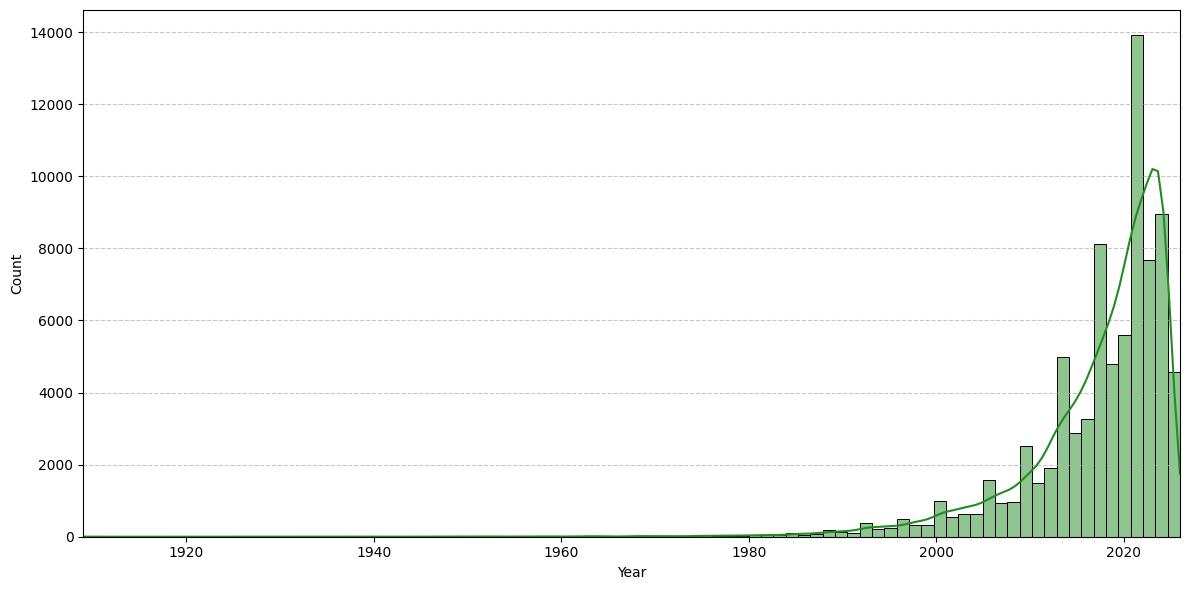

In [ ]:
# Sampled papers through the years

# Convert the 'year' column to numeric, forcing errors to NaN
years_numeric = pd.to_numeric(df_filtered_for_oldest['year'], errors='coerce')

# Drop NaN values
years_cleaned = years_numeric.dropna().astype(int)

# Plot the distribution of publication years
plt.figure(figsize=(12, 6))
sns.histplot(years_cleaned, bins=max(50, len(years_cleaned.unique())), kde=True, color='forestgreen')
# plt.title('Distribution of Publication Years for Filtered Graph DOIs')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(years_cleaned.min(), years_cleaned.max())
plt.tight_layout()
plt.show()

In [ ]:
# Filter for papers published in or after the year 2000
papers_after_2000 = df_filtered_for_oldest[df_filtered_for_oldest['year_numeric'] >= 2000]

# Calculate the share
total_papers = len(df_filtered_for_oldest)
papers_after_2000_count = len(papers_after_2000)

if total_papers > 0:
    share_after_2000 = (papers_after_2000_count / total_papers) * 100
    print(f"Share of publications in df_filtered_for_oldest that are from year 2000 or later: {share_after_2000:.2f}%")
else:
    print("No papers found in df_filtered_for_oldest to calculate the share.")

Share of publications in df_filtered_for_oldest that are from year 2000 or later: 96.16%


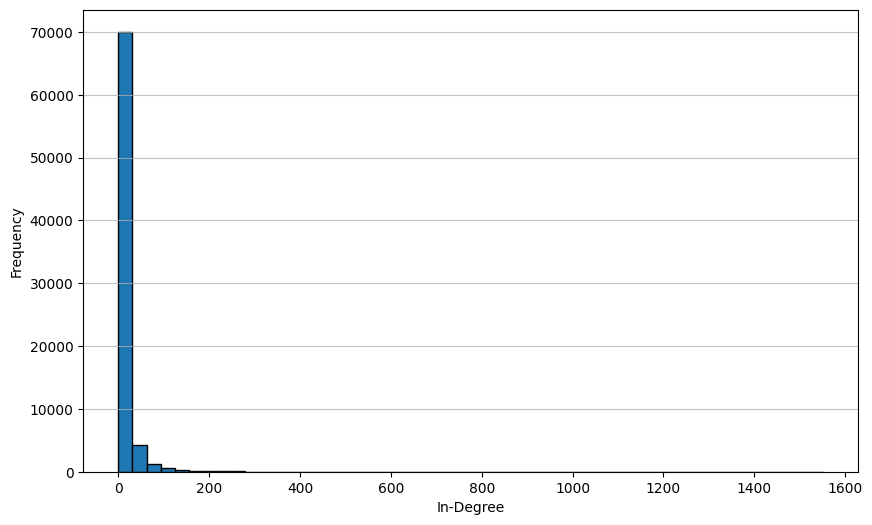

Mean In-Degree: 11.58
Maximum In-Degree: 1551
Mean of Top 10% In-Degrees: 71.10


In [ ]:

# Calculate indegrees for the filtered graph
indegrees_filtered = pd.Series([degree for node, degree in graph_filtered_by_communities.in_degree()])

# Plot histogram of indegrees
plt.figure(figsize=(10, 6))
plt.hist(indegrees_filtered, bins=50, edgecolor='black')
# plt.title('Histogram of Node In-Degrees in graph_filtered_by_communities')
plt.xlabel('In-Degree')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Calculate mean and max indegree
mean_indegree = indegrees_filtered.mean()
max_indegree = indegrees_filtered.max()
print(f"Mean In-Degree: {mean_indegree:.2f}")
print(f"Maximum In-Degree: {max_indegree}")

# Calculate the mean of the top 10% of indegrees
top_10_percent_count = int(len(indegrees_filtered) * 0.10)
sorted_indegrees = indegrees_filtered.sort_values(ascending=False)
mean_top_10_percent = sorted_indegrees.head(top_10_percent_count).mean()
print(f"Mean of Top 10% In-Degrees: {mean_top_10_percent:.2f}")

In [ ]:
import pandas as pd

# Get all in-degrees from the graph as a dictionary {node: degree}
in_degrees_dict = dict(graph_filtered_by_communities.in_degree())

# Sort the papers by indegree in descending order
sorted_papers_by_indegree = sorted(in_degrees_dict.items(), key=lambda item: item[1], reverse=True)

# Ensure df_info_full is loaded (it is already in kernel state, but good to be robust)
if 'df_info_full' not in locals():
    df_info_full = pd.read_parquet('df_info_full.parquet')

print("Top 10 papers with the highest indegree:")
print("---------------------------------------")

# Iterate through the top 10 papers and retrieve their information
for i, (doi, indegree_value) in enumerate(sorted_papers_by_indegree[:10]):
    paper_info_row = df_info_full[df_info_full['doi'] == doi]

    if not paper_info_row.empty:
        title = paper_info_row['citation-title'].iloc[0]
        year = paper_info_row['year'].iloc[0]

        print(f"\n{i+1}. Title: {title}")
        print(f"   DOI: {doi}")
        print(f"   Year: {year}")
        print(f"   In-Degree: {indegree_value}")
    else:
        print(f"\n{i+1}. Could not find metadata for DOI: {doi}. In-Degree: {indegree_value}")
        print("   This might indicate a data inconsistency where the DOI is in the graph but not in the metadata DataFrame.")


Top 10 papers with the highest indegree:
---------------------------------------

1. Title: A general framework for analyzing sustainability of social-ecological systems
   DOI: 10.1126/science.1172133
   Year: 2009
   In-Degree: 1551

2. Title: Challenges in integrating the concept of ecosystem services and values in landscape planning, management and decision making
   DOI: 10.1016/j.ecocom.2009.10.006
   Year: 2010
   In-Degree: 1108

3. Title: Global consequences of land use
   DOI: 10.1126/science.1111772
   Year: 2005
   In-Degree: 1094

4. Title: Adaptive governance of social-ecological systems
   DOI: 10.1146/annurev.energy.30.050504.144511
   Year: 2005
   In-Degree: 1051

5. Title: Defining and classifying ecosystem services for decision making
   DOI: 10.1016/j.ecolecon.2008.09.014
   Year: 2009
   In-Degree: 938

6. Title: Twenty years of ecosystem services: How far have we come and how far do we still need to go?
   DOI: 10.1016/j.ecoser.2017.09.008
   Year: 2017
   In-Deg

In [ ]:
# 1. Calculate Network Density
density = nx.density(graph_filtered_by_communities)
print(f"Network Density of graph_filtered_by_communities: {density:.6f}")

# 2. Calculate Network Diameter safely
# Diameter is typically defined for strongly connected directed graphs, or undirected graphs.
# We will find the largest weakly connected component and convert it to undirected to find the diameter.
if nx.is_weakly_connected(graph_filtered_by_communities):
    undirected_graph = graph_filtered_by_communities.to_undirected()
    print("Graph is weakly connected. Calculating diameter on undirected representation...")
    diameter = nx.diameter(undirected_graph)
    print(f"Network Diameter: {diameter}")
else:
    print("Graph is disconnected. Finding the largest weakly connected component to calculate diameter...")
    components = list(nx.weakly_connected_components(graph_filtered_by_communities))
    largest_component = max(components, key=len)
    subgraph_largest = graph_filtered_by_communities.subgraph(largest_component).to_undirected()
    print(f"Largest component has {len(subgraph_largest.nodes())} nodes out of {len(graph_filtered_by_communities.nodes())}.")
    # For very large components, diameter calculation can be slow, so we calculate an approximation
    try:
        approx_diameter = nx.approximation.diameter(subgraph_largest)
        print(f"Approximate Network Diameter (Largest Component): {approx_diameter}")
    except Exception as e:
        print(f"Could not calculate approximate diameter: {e}")

Network Density of graph_filtered_by_communities: 0.000150
Graph is disconnected. Finding the largest weakly connected component to calculate diameter...
Largest component has 76584 nodes out of 77001.
Approximate Network Diameter (Largest Component): 11


In [ ]:
# Get the largest weakly connected component as an undirected subgraph (already calculated in cell 95f4377b)
components = list(nx.weakly_connected_components(graph_filtered_by_communities))
largest_component = max(components, key=len)
subgraph_largest = graph_filtered_by_communities.subgraph(largest_component).to_undirected()

print(f"Calculating average shortest path length for the largest component ({len(subgraph_largest.nodes())} nodes)...\nThis may take a moment.")

try:
    # Using a sample of nodes to estimate/calculate depending on performance, or exact if possible.
    # For ~76k nodes, exact calculation will take too long. We will compute an approximation using sampling.
    import random
    sample_size = 1000
    random.seed(123)
    sampled_nodes = random.sample(list(subgraph_largest.nodes()), sample_size)

    path_lengths = []
    for node in sampled_nodes:
        lengths = nx.single_source_shortest_path_length(subgraph_largest, node)
        path_lengths.extend(lengths.values())

    avg_path_length_approx = sum(path_lengths) / len(path_lengths)
    print(f"Estimated Average Path Length (sampled {sample_size} nodes): {avg_path_length_approx:.4f}")
except Exception as e:
    print(f"Error calculating path length: {e}")

Calculating average shortest path length for the largest component (76584 nodes)...
This may take a moment.
Estimated Average Path Length (sampled 1000 nodes): 4.0249


In [ ]:
# Now some descriptives
# funding-agency-matched-string; country; organization; journal

In [ ]:
df_filtered_for_oldest.columns

Index(['funding-agency-matched-string', 'xocs:funding-id', 'country',
       '@country', 'organization_$', 'affiliation-id_@afid', 'given_name',
       '@author-instance-id', '@auid', 'citation-title', 'abstract',
       'author_keywords', 'journal', 'year', 'issn', 'grant-acronym',
       'grant-agency_@iso-code', 'grant-agency-id', 'eid', 'doi',
       'references_file_name', 'references_file_index', 'cited_by_file_name',
       'cited_by_file_index', 'year_numeric'],
      dtype='object')

In [ ]:
df_filtered_for_oldest['affiliation-id_@afid']

,affiliation-id_@afid
0,60027152; 60027152; 60027152
2,60111782; 60008134; 60083820; 60108488; 601231...
3,60117141; 60008734
5,60016849; 60016849
6,60006173
...,...
328340,60012708
328345,
328346,60008950
328347,60002952; 60002952; 60002952; 60069393; 114357...


In [ ]:
# Top affiliations - need to look at the meaning of the codes in SCOPUS manually
# This is better / more consistent than the columns where affiliations are written... sometimes they write just the department

# Drop NaN values and ensure string format
affiliation_series = df_filtered_for_oldest['affiliation-id_@afid'].dropna().astype(str)

# Split entries by semicolon and strip whitespace
all_affiliations = []
for entry in affiliation_series:
    splitted = [aff.strip() for aff in entry.split(';') if aff.strip()]
    all_affiliations.extend(splitted)

# Calculate and display value counts for the top 50 affiliations
affiliation_counts = pd.Series(all_affiliations).value_counts()
print(f"Total unique affiliation ID mentions: {len(affiliation_counts)}")
print("\nTop 50 most frequent affiliation IDs:")
display(affiliation_counts.head(50))

Total unique affiliation ID mentions: 32246

Top 50 most frequent affiliation IDs:


,count
60004156,3067
60019499,1722
60008134,1444
60031004,1437
60002952,1410
60027152,1380
60123163,1372
60010365,1304
60026851,1202
60031011,1160


In [ ]:
# Top countries

# Drop NaN values in the country column
country_series = df_filtered_for_oldest['country'].dropna().astype(str)

# Split entries by semicolon and strip leading/trailing whitespace
all_countries = []
for entry in country_series:
    splitted = [c.strip() for c in entry.split(';') if c.strip()]
    all_countries.extend(splitted)

# Create a Series and get the value counts
country_counts = pd.Series(all_countries).value_counts()

print("Total unique country mentions count:", len(country_counts))
print("\nTop 50 most frequent countries:")
display(country_counts.head(50))

Total unique country mentions count: 213

Top 50 most frequent countries:


,count
United States,44878
United Kingdom,19987
China,15569
Germany,13667
Australia,13241
Canada,9571
Brazil,8266
Netherlands,8026
Spain,6298
France,6209


In [ ]:
# Top funding agencies

# Drop NaN values in the funding agency column and ensure string conversion
funding_series = df_filtered_for_oldest['funding-agency-matched-string'].dropna().astype(str)

# Split entries by semicolon and strip leading/trailing whitespace
all_funders = []
for entry in funding_series:
    splitted = [f.strip() for f in entry.split(';') if f.strip()]
    all_funders.extend(splitted)

# Create a Series and get the value counts
funder_counts = pd.Series(all_funders).value_counts()

print("Total unique funding agency mentions count:", len(funder_counts))
print("\nTop 50 most frequent funding agencies:")
display(funder_counts.head(50))

Total unique funding agency mentions count: 42306

Top 50 most frequent funding agencies:


,count
National Natural Science Foundation of China,3681
National Science Foundation,2049
European Commission,849
Australian Research Council,830
CNPq,807
European Union,755
Academy of Finland,725
European Research Council,637
NSF,543
BMBF,538


In [ ]:
# Cross-tabulation of funding agencies and topics

# 1. Map each DOI in our filtered graph to its community affiliation
doi_to_community = {}
for node in graph_filtered_by_communities.nodes():
    affiliation = graph_filtered_by_communities.nodes[node].get('community_affiliation', 'unassigned')
    # Clean double asterisks if present in the stored names
    cleaned_affiliation = affiliation.replace('**', '').strip()
    # Handle specific names for consistency with previous legend cleaning
    if cleaned_affiliation == 'Community_community_44':
        cleaned_affiliation = 'Forests in Carbon Dioxide Removal'
    elif cleaned_affiliation == '99-ungrouped':
        cleaned_affiliation = 'Ungrouped'
    doi_to_community[node] = cleaned_affiliation

# 2. Extract DOIs, their communities, and their corresponding funding agencies
data_records = []
for doi, community in doi_to_community.items():
    # Look up the row in df_filtered_for_oldest
    paper_row = df_filtered_for_oldest[df_filtered_for_oldest['doi'] == doi]
    if not paper_row.empty:
        funding_val = paper_row['funding-agency-matched-string'].iloc[0]
        if pd.notna(funding_val) and str(funding_val).strip() != '':
            # Split by semicolon and clean
            agencies = [agency.strip() for agency in str(funding_val).split(';') if agency.strip()]
            for agency in agencies:
                data_records.append({'doi': doi, 'community': community, 'funding_agency': agency})

# Convert to a DataFrame
df_doi_community_funder = pd.DataFrame(data_records)

# 3. Identify the top 30 funding agencies in this set of records
top_30_funders = df_doi_community_funder['funding-agency-matched-string' if 'funding-agency-matched-string' in df_doi_community_funder.columns else 'funding_agency'].value_counts().head(30).index.tolist()

# Filter the DataFrame to contain only these top 30 funders
df_top_funders = df_doi_community_funder[df_doi_community_funder['funding_agency'].isin(top_30_funders)]

# 4. Create the cross-tabulation (contingency table)
cross_tab = pd.crosstab(
    index=df_top_funders['funding_agency'],
    columns=df_top_funders['community'],
    margins=True,
    margins_name='Total'
)

# Sort the index of the cross-tab so that the funders are ordered by their overall popularity (highest first)
cross_tab = cross_tab.reindex(top_30_funders + ['Total'])

# Display the cross-tabulation table
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
display(cross_tab)

community,Agent-Based Modeling in Land Use Systems,Community Governance of Natural Resources,Desertification and Land Degradation Dynamics,Diverse Forest Owners,Ecosystem Services Integration,Forest Certification and Sustainable Management,Forests and Rural Livelihoods,Forests in Carbon Dioxide Removal,Global Forest Conservation and Deforestation Dynamics,Payments for Environmental Services (PES),Stated Preference Methods in Environmental Valuation,Sustaining Resilience Through Transformative Collaboration,Ungrouped,Total
funding_agency,,,,,,,,,,,,,,
National Natural Science Foundation of China,20,186,2,54,1667,35,172,45,739,255,232,248,0,3655
National Science Foundation,15,353,1,79,272,10,45,19,496,172,82,469,0,2013
European Commission,3,88,3,36,180,13,47,18,106,130,50,154,0,828
Australian Research Council,0,82,0,12,112,7,4,14,197,90,54,255,0,827
CNPq,0,31,0,4,76,8,32,2,521,52,7,65,0,798
European Union,6,83,2,34,170,19,42,24,115,76,38,126,2,737
Academy of Finland,0,45,0,162,95,30,8,4,92,48,29,152,0,665
European Research Council,2,77,0,10,63,2,23,42,197,34,15,169,0,634
BMBF,2,34,0,29,128,4,26,35,93,41,18,123,0,533


In [ ]:
# Organization by topic


# 1. Map each DOI in our filtered graph to its community affiliation
doi_to_community = {}
for node in graph_filtered_by_communities.nodes():
    affiliation = graph_filtered_by_communities.nodes[node].get('community_affiliation', 'unassigned')
    # Clean double asterisks if present in the stored names
    cleaned_affiliation = affiliation.replace('**', '').strip()
    # Handle specific names for consistency with previous legend cleaning
    if cleaned_affiliation == 'Community_community_44':
        cleaned_affiliation = 'Forests in Carbon Dioxide Removal'
    elif cleaned_affiliation == '99-ungrouped':
        cleaned_affiliation = 'Ungrouped'
    doi_to_community[node] = cleaned_affiliation

# 2. Extract DOIs, their communities, and their corresponding affiliation IDs
affiliation_records = []
for doi, community in doi_to_community.items():
    paper_row = df_filtered_for_oldest[df_filtered_for_oldest['doi'] == doi]
    if not paper_row.empty:
        aff_val = paper_row['affiliation-id_@afid'].iloc[0]
        if pd.notna(aff_val) and str(aff_val).strip() != '':
            # Split by semicolon and clean
            affs = [aff.strip() for aff in str(aff_val).split(';') if aff.strip()]
            for aff in affs:
                affiliation_records.append({'doi': doi, 'community': community, 'affiliation_id': aff})

# Convert to a DataFrame
df_doi_community_aff = pd.DataFrame(affiliation_records)

# 3. Identify the top 20 affiliation IDs in this filtered set
top_20_affs = df_doi_community_aff['affiliation_id'].value_counts().head(20).index.tolist()

# Filter the DataFrame to contain only these top 20 affiliations
df_top_affs = df_doi_community_aff[df_doi_community_aff['affiliation_id'].isin(top_20_affs)]

# 4. Create the cross-tabulation (contingency table)
aff_cross_tab = pd.crosstab(
    index=df_top_affs['affiliation_id'],
    columns=df_top_affs['community'],
    margins=True,
    margins_name='Total'
)

# Sort the index of the cross-tab so that the affiliation IDs are ordered by overall popularity (highest first)
aff_cross_tab = aff_cross_tab.reindex(top_20_affs + ['Total'])

# Display the cross-tabulation table
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
display(aff_cross_tab)

community,Agent-Based Modeling in Land Use Systems,Community Governance of Natural Resources,Desertification and Land Degradation Dynamics,Diverse Forest Owners,Ecosystem Services Integration,Forest Certification and Sustainable Management,Forests and Rural Livelihoods,Forests in Carbon Dioxide Removal,Global Forest Conservation and Deforestation Dynamics,Payments for Environmental Services (PES),Stated Preference Methods in Environmental Valuation,Sustaining Resilience Through Transformative Collaboration,Ungrouped,Total
affiliation_id,,,,,,,,,,,,,,
60004156,26,319,3,98,650,71,209,25,436,327,46,738,3,2951
60019499,10,99,0,15,759,5,60,10,511,109,44,81,3,1706
60008134,6,118,3,38,373,4,35,28,423,120,51,236,1,1436
60031004,5,148,2,23,180,7,19,30,501,178,43,283,2,1421
60123163,11,89,1,71,363,5,69,5,263,189,100,182,0,1348
60002952,0,67,0,210,256,45,38,1,272,113,21,297,2,1322
60027152,3,150,0,338,268,16,74,3,121,87,81,134,5,1280
60010365,1,166,0,106,227,72,59,12,224,106,16,252,2,1243
60026851,0,213,1,16,102,57,30,60,313,121,11,244,3,1171


# These brokerage roles are on node-level (i.e. per paper)
for the overall sample, this is too detailed
Use this if you're focusing on a sub-sample / topic
This is not included in the paper

In [ ]:
# Brokerage roles per Gould and Fernandez
from collections import defaultdict

# Ensure we use the directed filtered graph to accurately compute brokerage flows (Source -> Broker -> Target)
G_directed = graph_filtered_by_communities

# 1. Map nodes to their cleaned community affiliations
node_to_comm = {}
for node in G_directed.nodes():
    affiliation = G_directed.nodes[node].get('community_affiliation', 'unassigned')
    cleaned = affiliation.replace('**', '').strip()
    if cleaned == 'Community_community_44':
        cleaned = 'Forests in Carbon Dioxide Removal'
    elif cleaned == '99-ungrouped':
        cleaned = 'Ungrouped'
    node_to_comm[node] = cleaned

# 2. Initialize dictionaries to store brokerage role counts for each node
coordinator = defaultdict(int)
itinerary = defaultdict(int)
representative = defaultdict(int)
gatekeeper = defaultdict(int)
liaison = defaultdict(int)

# 3. Compute brokerage roles by examining two-step paths: source -> broker -> target
print("Calculating Gould-Fernandez brokerage roles... This might take a moment.")

for broker in G_directed.nodes():
    broker_comm = node_to_comm.get(broker, 'unassigned')
    if broker_comm == 'unassigned' or broker_comm == 'Ungrouped':
        continue

    # In-neighbors (sources) and Out-neighbors (targets)
    sources = list(G_directed.predecessors(broker))
    targets = list(G_directed.successors(broker))

    if not sources or not targets:
        continue

    for u in sources:
        source_comm = node_to_comm.get(u, 'unassigned')
        if source_comm == 'unassigned' or source_comm == 'Ungrouped':
            continue

        for v in targets:
            if u == v: # skip self-loops
                continue
            target_comm = node_to_comm.get(v, 'unassigned')
            if target_comm == 'unassigned' or target_comm == 'Ungrouped':
                continue

            # Classify path based on community of Source (u), Broker (broker), and Target (v)
            if source_comm == broker_comm and target_comm == broker_comm:
                coordinator[broker] += 1
            elif source_comm == target_comm and source_comm != broker_comm:
                itinerary[broker] += 1
            elif source_comm == broker_comm and target_comm != broker_comm:
                representative[broker] += 1
            elif target_comm == broker_comm and source_comm != broker_comm:
                gatekeeper[broker] += 1
            elif source_comm != broker_comm and target_comm != broker_comm and source_comm != target_comm:
                liaison[broker] += 1

# 4. Compile into a DataFrame
brokerage_records = []
for node in G_directed.nodes():
    brokerage_records.append({
        'doi': node,
        'community': node_to_comm.get(node, 'unassigned'),
        'Coordinator': coordinator[node],
        'Itinerary': itinerary[node],
        'Representative': representative[node],
        'Gatekeeper': gatekeeper[node],
        'Liaison': liaison[node],
        'Total_Brokerage': coordinator[node] + itinerary[node] + representative[node] + gatekeeper[node] + liaison[node]
    })

df_gould_fernandez = pd.DataFrame(brokerage_records)

# Merge with metadata for paper titles
df_info_unique = df_info_full.drop_duplicates(subset=['doi'])
df_gf_merged = pd.merge(df_gould_fernandez, df_info_unique[['doi', 'citation-title']], on='doi', how='left')

# Show top brokers for each category
roles = ['Coordinator', 'Itinerary', 'Representative', 'Gatekeeper', 'Liaison', 'Total_Brokerage']
for role in roles:
    print(f"\n--- Top 5 Brokers in role: {role} ---")
    top_role_df = df_gf_merged.sort_values(by=role, ascending=False).head(5)
    display(top_role_df[['citation-title', 'community', role]])


Calculating Gould-Fernandez brokerage roles... This might take a moment.

--- Top 5 Brokers in role: Coordinator ---


,citation-title,community,Coordinator
49125,Contemporary guidance for stated preference st...,Stated Preference Methods in Environmental Val...,60151
27132,Twenty years of ecosystem services: How far ha...,Ecosystem Services Integration,21120
74244,Integrating socio-cultural perspectives into e...,Ecosystem Services Integration,17236
74709,Challenges in integrating the concept of ecosy...,Ecosystem Services Integration,17208
55140,Contributions of cultural services to the ecos...,Ecosystem Services Integration,17143



--- Top 5 Brokers in role: Itinerary ---


,citation-title,community,Itinerary
69350,Adaptive governance of social-ecological systems,Community Governance of Natural Resources,6720
58024,Community managed forests and forest protected...,Community Governance of Natural Resources,4287
40215,Conservation social science: Understanding and...,Sustaining Resilience Through Transformative C...,3131
75755,Getting the message right on nature-based solu...,Ecosystem Services Integration,2275
29782,The history of ecosystem services in economic ...,Ecosystem Services Integration,1781



--- Top 5 Brokers in role: Representative ---


...

,citation-title,community,Gatekeeper
49125,Contemporary guidance for stated preference st...,Stated Preference Methods in Environmental Val...,10658
69350,Adaptive governance of social-ecological systems,Community Governance of Natural Resources,9795
44733,Environmental Income and Rural Livelihoods: A ...,Forests and Rural Livelihoods,8888
22094,Beyond markets and states: Polycentric governa...,Community Governance of Natural Resources,7227
74606,Evolution of co-management: Role of knowledge ...,Community Governance of Natural Resources,6820



--- Top 5 Brokers in role: Liaison ---


,citation-title,community,Liaison
40215,Conservation social science: Understanding and...,Sustaining Resilience Through Transformative C...,6949
4049,Using perceptions as evidence to improve conse...,Community Governance of Natural Resources,3856
75755,Getting the message right on nature-based solu...,Ecosystem Services Integration,3665
64373,Hard choices: Making trade-offs between biodiv...,Global Forest Conservation and Deforestation D...,3578
4894,Global warming of 1.5°C: An IPCC Special Repor...,Sustaining Resilience Through Transformative C...,3253



--- Top 5 Brokers in role: Total_Brokerage ---


,citation-title,community,Total_Brokerage
49125,Contemporary guidance for stated preference st...,Stated Preference Methods in Environmental Val...,72264
69350,Adaptive governance of social-ecological systems,Community Governance of Natural Resources,31528
27132,Twenty years of ecosystem services: How far ha...,Ecosystem Services Integration,28560
74709,Challenges in integrating the concept of ecosy...,Ecosystem Services Integration,24376
55140,Contributions of cultural services to the ecos...,Ecosystem Services Integration,23829


Coordinator: Source, broker, and target belong to the same community.
Itinerary (Consultant): Source and target belong to community A; broker belongs to community B.
Representative: Source and broker belong to community A; target belongs to community B.
Gatekeeper: Source belongs to community A; broker and target belong to community B.
Liaison: All three belong to different communities.

### Boundary-Spanning and Structural Holes Analysis

To identify which papers serve as bridges or boundary-spanners between distinct thematic forest policy communities, we will calculate several structural metrics without using sampling:

1. **Betweenness Centrality**: Measures how often a node lies on the shortest paths between all other node pairs in the network. Nodes with high betweenness act as critical gatekeepers or bottlenecks controlling information flow across different communities.
2. **Burt's Constraint**: Measures the extent to which a node's network partners are already connected to one another (redundancy). A **low constraint score** indicates that a paper connects to diverse, otherwise disconnected groups, representing high boundary-spanning capacity and access to unique structural holes.
3. **Effective Size**: Measures the number of unique, non-redundant contacts a node has. Higher values indicate that the paper's connections are scattered across disparate communities rather than clumped within a single dense cluster.

In [ ]:
# All three measures, saved to Excel per community

import multiprocessing as mp
import re

# Ensure we are using the filtered graph
G = graph_filtered_by_communities

# Define parallel chunk functions
def _compute_constraint_chunk(G, nodes):
    return nx.constraint(G, nodes=nodes)

def _compute_effective_size_chunk(G, nodes):
    return nx.effective_size(G, nodes=nodes)

def parallel_metrics(G, num_cores=None):
    if num_cores is None:
        num_cores = mp.cpu_count()

    nodes = list(G.nodes())
    if not nodes:
        return {}, {}, {}

    chunk_size = max(1, len(nodes) // num_cores)
    node_chunks = [nodes[i:i + chunk_size] for i in range(0, len(nodes), chunk_size)]

    pool = mp.Pool(processes=num_cores)
    # Compute in parallel
    con_results = pool.starmap(_compute_constraint_chunk, [(G, chunk) for chunk in node_chunks])
    eff_results = pool.starmap(_compute_effective_size_chunk, [(G, chunk) for chunk in node_chunks])

    pool.close()
    pool.join()

    # Combine results
    # Betweenness centrality does not support node chunking via the public API,
    # so we compute it sequentially for the community subgraph.
    betweenness = nx.betweenness_centrality(G, normalized=True)

    constraint = {}
    for res in con_results:
        constraint.update(res)

    effective_size = {}
    for res in eff_results:
        effective_size.update(res)

    return betweenness, constraint, effective_size

# Get all unique communities (excluding 'unassigned' or 'Ungrouped' if necessary)
communities = set(nx.get_node_attributes(G, 'community_affiliation').values())

df_info_unique = df_info_full.drop_duplicates(subset=['doi'])
all_top_results = []
community_results_dict = {} # Store results per community for Excel sheets

for comm in communities:
    cleaned_comm = comm.replace('**', '').strip()
    if cleaned_comm == 'unassigned' or cleaned_comm == 'Ungrouped':
        continue

    print(f"Processing community: {cleaned_comm}")

    # 1. Isolate the community subgraph
    comm_nodes = [n for n, attr in G.nodes(data=True) if attr.get('community_affiliation', '').replace('**', '').strip() == cleaned_comm]
    sub_G = G.subgraph(comm_nodes).copy()  # Added .copy() to make it picklable

    if len(comm_nodes) == 0:
        continue

    # 2. Calculate metrics for the community subgraph in PARALLEL
    print(f"  - Calculating Exact Betweenness, Constraint, and Effective Size for {len(comm_nodes)} nodes...")
    betweenness, constraint, effective_size = parallel_metrics(sub_G)

    # 3. Compile into a DataFrame
    boundary_data = []
    for node in sub_G.nodes():
        boundary_data.append({
            'doi': node,
            'community': cleaned_comm,
            'Betweenness_Centrality': betweenness.get(node, 0.0),
            'Constraint': constraint.get(node, 1.0), # Default to high constraint if isolated
            'Effective_Size': effective_size.get(node, 1.0)
        })

    df_comm = pd.DataFrame(boundary_data)
    df_comm = pd.merge(df_comm, df_info_unique[['doi', 'citation-title']], on='doi', how='left')

    # 4. Extract Top 10 for each criterion
    top_bet = df_comm.sort_values(by='Betweenness_Centrality', ascending=False).head(10)
    top_bet['Criterion'] = 'Highest Betweenness Centrality'

    top_con = df_comm.sort_values(by='Constraint', ascending=True).head(10)
    top_con['Criterion'] = 'Lowest Constraint (Burt)'

    top_eff = df_comm.sort_values(by='Effective_Size', ascending=False).head(10)
    top_eff['Criterion'] = 'Highest Effective Size'

    # Combine for this community
    comm_top = pd.concat([top_bet, top_con, top_eff], ignore_index=True)

    # Reorder columns
    columns_order = ['community', 'Criterion', 'doi', 'citation-title', 'Betweenness_Centrality', 'Constraint', 'Effective_Size']
    comm_top = comm_top[[col for col in columns_order if col in comm_top.columns]]

    community_results_dict[cleaned_comm] = comm_top
    all_top_results.extend([top_bet, top_con, top_eff])

# 5. Combine and save to Excel
if community_results_dict:
    excel_file = 'boundary_spanning_top10_per_community.xlsx'
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        for comm_name, df_result in community_results_dict.items():
            # Sheet names must be <= 31 chars and valid
            sheet_name = re.sub(r'[\[\]\\/*?:&]', '', comm_name)[:31]
            df_result.to_excel(writer, sheet_name=sheet_name, index=False)

    print(f"\nAnalysis completed successfully. Top 10 papers per criterion per community saved to '{excel_file}' in separate sheets.")

    # display first few rows of the first community as a sample
    first_comm = list(community_results_dict.keys())[0]
    display(community_results_dict[first_comm].head(30))
else:
    print("No data to process.")


Processing community: Payments for Environmental Services (PES)
  - Calculating Exact Betweenness, Constraint, and Effective Size for 7065 nodes...
Processing community: Sustaining Resilience Through Transformative Collaboration
  - Calculating Exact Betweenness, Constraint, and Effective Size for 14676 nodes...
Processing community: Agent-Based Modeling in Land Use Systems
  - Calculating Exact Betweenness, Constraint, and Effective Size for 375 nodes...
Processing community: Forests and Rural Livelihoods
  - Calculating Exact Betweenness, Constraint, and Effective Size for 3827 nodes...
Processing community: Community Governance of Natural Resources
  - Calculating Exact Betweenness, Constraint, and Effective Size for 10431 nodes...
Processing community: Stated Preference Methods in Environmental Valuation
  - Calculating Exact Betweenness, Constraint, and Effective Size for 5307 nodes...
Processing community: Forest Certification and Sustainable Management
  - Calculating Exact Betw

,community,Criterion,doi,citation-title,Betweenness_Centrality,Constraint,Effective_Size
0,Payments for Environmental Services (PES),Highest Betweenness Centrality,10.4337/9781802200416.ch71,Payments for ecosystem services,0.062429,0.028690,36.024390
1,Payments for Environmental Services (PES),Highest Betweenness Centrality,10.1515/9781474477284,Managing Scotland's Environment,0.043880,0.037953,38.521277
2,Payments for Environmental Services (PES),Highest Betweenness Centrality,10.1016/j.agee.2005.09.003,Adopting sustainable farm management practices...,0.042650,0.059185,21.615385
3,Payments for Environmental Services (PES),Highest Betweenness Centrality,10.1016/j.ecoser.2013.09.008,Payments for water ecosystem services in Latin...,0.040590,0.016477,76.325581
4,Payments for Environmental Services (PES),Highest Betweenness Centrality,10.1016/j.landusepol.2011.06.012,Encouraging collaboration for the provision of...,0.033615,0.018594,74.275000
5,Payments for Environmental Services (PES),Highest Betweenness Centrality,10.1093/oxrep/grs002,How should we incentivize private landowners t...,0.021126,0.011810,113.184874
6,Payments for Environmental Services (PES),Highest Betweenness Centrality,10.1016/j.cosust.2012.11.001,Designing payments for ecosystem services sche...,0.018636,0.015087,80.955056
7,Payments for Environmental Services (PES),Highest Betweenness Centrality,10.1146/annurev-resource-100518-094206,Payments for environmental services: Past perf...,0.016309,0.009150,167.341667
8,Payments for Environmental Services (PES),Highest Betweenness Centrality,10.1016/j.landusepol.2021.105620,Agri-environmental schemes for biodiversity an...,0.015457,0.022222,55.682540
9,Payments for Environmental Services (PES),Highest Betweenness Centrality,10.1086/718212,"European Agri-environmental Policy: Evolution,...",0.013727,0.024641,48.472727


In [ ]:
# Some useful links
# https://networkx.org/documentation/stable/reference/algorithms/community.html
# https://github.com/esclear/louvain-leiden?tab=readme-ov-file#sample-notebooks
# https://www.nature.com/articles/s41598-019-41695-z
# https://medium.com/@adiyaochir/getting-started-with-python-igraph-a-comprehensive-guide-with-examples-3386820990c1
# https://igraph.org/python/tutorial/0.9.6/visualisation.html

## 10 oldest papers

In [ ]:
import pandas as pd

# Get all DOIs from the filtered graph
dois_in_filtered_graph = set(graph_filtered_by_communities.nodes())

# Filter df_info_full to include only papers present in the filtered graph
df_filtered_papers = df_info_full[df_info_full['doi'].isin(dois_in_filtered_graph)].copy()

# Convert 'year' to numeric, coercing errors to NaN
df_filtered_papers['year_numeric'] = pd.to_numeric(df_filtered_papers['year'], errors='coerce')

# Sort by year_numeric and get the top 10 oldest papers
df_oldest_papers_in_filtered_graph = df_filtered_papers.sort_values(by='year_numeric', ascending=True).head(20)

# Display the relevant columns
display(df_oldest_papers_in_filtered_graph[['citation-title', 'year', 'doi']])

,citation-title,year,doi
327928,Coillte: Con,1878,10.1093/nq/s5-X.248.251
11947,Coillte: Con,1878,10.1093/nq/s5-X.248.251
9657,Two unpublished letters of Thackeray and Havelock,1881,10.1093/nq/s6-iv.104.507b
328089,Two unpublished letters of Thackeray and Havelock,1881,10.1093/nq/s6-iv.104.507b
32242,IX. Descriptions of new genera and species of ...,1883,10.1111/j.1365-2311.1883.tb02945.x
326363,IX. Descriptions of new genera and species of ...,1883,10.1111/j.1365-2311.1883.tb02945.x
327033,The water supply of Dublin,1899,10.1007/BF02949548
11346,The water supply of Dublin,1899,10.1007/BF02949548
326823,On a method of mechanically reinforcing sounds,1903,10.1088/1478-7814/19/1/304
45630,On a method of mechanically reinforcing sounds,1903,10.1088/1478-7814/19/1/304


#LLM

In [ ]:
# Prepare the data for LLM's

# Create DataFrame for DOIs_out_of_sample with label 0
df_out_of_sample = pd.DataFrame({
    'DOI': DOIs_out_of_sample,
    'sample': 0
})
# Create DataFrame for DOIs_in_sample with label 1
df_in_sample = pd.DataFrame({
    'DOI': DOIs_in_sample,
    'sample': 1
})
# Concatenate the two DataFrames
df_combined_samples = pd.concat([df_out_of_sample, df_in_sample], ignore_index=True)
# Merge with df_info_full to get abstracts
df_final_data = pd.merge(
    df_combined_samples,
    df_info_full[['doi', 'abstract']],
    left_on='DOI',
    right_on='doi',
    how='left'
)
# Drop the redundant 'doi' column from the merge and handle potential NaN abstracts
df_final_data = df_final_data.drop(columns=['doi'])
df_final_data['abstract'] = df_final_data['abstract'].fillna('')
# remove rows in df_final_data where abstract is empty
df_final_data = df_final_data[df_final_data['abstract'] != ''].reset_index(drop=True)


df_info_full_unique_doi = df_info_full.drop_duplicates(subset=['doi'])
doi_to_title_map = df_info_full_unique_doi.set_index('doi')['citation-title']

# Get the corresponding citation-titles for df_final_data['DOI']
titles_to_prepend = df_final_data['DOI'].map(doi_to_title_map).fillna('')

# Prepend titles to abstracts, handling potential NaN in abstracts
df_final_data['abstract'] = titles_to_prepend.astype(str) + '. ' + df_final_data['abstract'].astype(str)

# Rename the 'abstract' column to 'title_abstract'
df_final_data.rename(columns={'abstract': 'title_abstract'}, inplace=True)

df_final_data = df_final_data.sample(frac=1).reset_index(drop=True)  # Shuffle the data randomly

# split all_data randomly to train_dataset and test_dataset, where 80% goes to train_dataset
train_size = int(0.8 * len(df_final_data))
train_dataset = df_final_data[:train_size]
test_dataset = df_final_data[train_size:]

In [ ]:
df_final_data.to_csv('Test_EUFORE_classification_for_LLM.csv', index=False)

In [ ]:
#### END OF SEPARATE RUN

# BERT CLASSIFICATION

In [ ]:
# https://medium.com/@tossy21/fine-tuning-modernbert-on-imdb-movie-review-comments-for-text-classification-0df8ace77259

In [ ]:
model = ModernBertForSequenceClassification.from_pretrained('answerdotai/ModernBERT-base')
tokenizer = AutoTokenizer.from_pretrained('answerdotai/ModernBERT-base')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

In [ ]:
# tokenize the data
train_dataset = Dataset.from_list(train_dataset.to_dict('records'))
test_dataset = Dataset.from_list(test_dataset.to_dict('records'))

def tokenize(batch):
    return tokenizer(batch['title_abstract'], truncation=True, padding="max_length", max_length=512)


train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)
train_dataset = train_dataset.rename_column("sample", "label")
test_dataset = test_dataset.rename_column("sample", "label")

train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/37749 [00:00<?, ? examples/s]

Map:   0%|          | 0/9438 [00:00<?, ? examples/s]

In [ ]:
#  make a trainer and train on train_dataset and  test_dataset


# Assuming model and tokenizer are already defined and loaded
# model = ModernBertForSequenceClassification.from_pretrained('answerdotai/ModernBERT-base')
# tokenizer = AutoTokenizer.from_pretrained('answerdotai/ModernBERT-base')

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    fp16=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

# Train the model
trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Step,Training Loss
500,0.537546
1000,0.501682
1500,0.422552
2000,0.364744
2500,0.404509
3000,0.358862
3500,0.355420
4000,0.355917
4500,0.357581
5000,0.339769


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=9438, training_loss=0.36371987147411067, metrics={'train_runtime': 2060.9791, 'train_samples_per_second': 18.316, 'train_steps_per_second': 4.579, 'total_flos': 1.2863267929257984e+16, 'train_loss': 0.36371987147411067, 'epoch': 1.0})

In [ ]:
trainer.evaluate()

Training Loss,Validation Loss,Step,Accuracy,F1,Precision,Recall
0.293381,0.338809,9438,0.892562,0.883421,0.842359,0.928692


{'eval_loss': 0.3388087749481201,
 'eval_accuracy': 0.8925619834710744,
 'eval_f1': 0.8834214762014256,
 'eval_precision': 0.8423591317693488,
 'eval_recall': 0.9286922890983804}

In [ ]:
# prompt: use trainer to predict labels for test_dataset['text']

import numpy as np
from transformers import Trainer

# Assuming 'trainer' and 'test_dataset' are already defined and loaded as in your provided code.

predictions = trainer.predict(test_dataset)
predicted_labels = np.argmax(predictions.predictions, axis=1)

# Now 'predicted_labels' contains the predicted labels for test_dataset['text']
predicted_labels


array([1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1])

In [ ]:
# Now predict for it all

In [ ]:
df_for_prediction = df_info_full[['doi', 'citation-title', 'abstract']].copy()

# Handle potential NaN values by filling with empty strings before concatenation
df_for_prediction['citation-title'] = df_for_prediction['citation-title'].fillna('')
df_for_prediction['abstract'] = df_for_prediction['abstract'].fillna('')

# Combine title and abstract into a new column
df_for_prediction['title_abstract'] = df_for_prediction['citation-title'] + '. ' + df_for_prediction['abstract']

# Remove rows where the combined title_abstract is empty after concatenation
df_for_prediction = df_for_prediction[df_for_prediction['title_abstract'].str.strip() != ''].reset_index(drop=True)

# Convert DataFrame to Hugging Face Dataset
predict_dataset_hf = Dataset.from_pandas(df_for_prediction)

# Tokenize the dataset using the existing tokenizer
def tokenize_for_prediction(batch):
    return tokenizer(batch['title_abstract'], truncation=True, padding="max_length", max_length=512)

predict_dataset_tokenized = predict_dataset_hf.map(tokenize_for_prediction, batched=True)

# Set the format for PyTorch tensors, as expected by the Trainer
predict_dataset_tokenized.set_format('torch', columns=['input_ids', 'attention_mask'])

# Use the trained trainer to make predictions
predictions_output = trainer.predict(predict_dataset_tokenized)

# Extract predicted labels (0 or 1) from the logits
predicted_labels = np.argmax(predictions_output.predictions, axis=1)

# Add the predicted 'sample' column to the new DataFrame
df_for_prediction['sample'] = predicted_labels

print("Prediction complete. Displaying the first 5 rows of the new DataFrame with 'sample' column:")
display(df_for_prediction.head())

Map:   0%|          | 0/328355 [00:00<?, ? examples/s]

Prediction complete. Displaying the first 5 rows of the new DataFrame with 'sample' column:


,doi,citation-title,abstract,title_abstract,sample
0,10.1016/j.forpol.2016.07.010,Envisioning future forested landscapes in Swed...,Governance of forested landscapes must account...,Envisioning future forested landscapes in Swed...,1
1,10.1016/j.forpol.2020.102218,Optimal rotations with declining discount rate...,Schedules of declining discount rates have bee...,Optimal rotations with declining discount rate...,1
2,10.1016/j.forpol.2021.102459,Farmers' preferences for water-saving strategi...,"In a climate change context, changing temperat...",Farmers' preferences for water-saving strategi...,1
3,10.1016/j.forpol.2008.10.003,Partnerships for sustainable development as di...,Partnerships for sustainable development are t...,Partnerships for sustainable development as di...,1
4,10.1016/j.forpol.2007.06.003,Evaluation of renewable energy policies in an ...,This paper evaluates socio-economic impacts of...,Evaluation of renewable energy policies in an ...,1


In [ ]:
df_for_prediction['sample'].describe()

,sample
count,328355.000000
mean,0.340778
std,0.473971
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [ ]:
df_for_prediction.to_csv('df_info_BERT_classification.csv', index=False)

# CHUNK ON LLM - OLLAMA

In [ ]:
# Run this separately from everything else!!!!

### Installing and Running Ollama
https://colab.research.google.com/github/5aharsh/collama/blob/main/Ollama_Setup.ipynb#scrollTo=YlVK9iG4AD5L

In [ ]:
!sudo apt-get install zstd
!sudo apt update
!sudo apt install -y pciutils
!curl -fsSL https://ollama.com/install.sh | sh
!pip install langchain_ollama

In [ ]:
import threading
import subprocess
import time

def run_ollama_serve():
  subprocess.Popen(["ollama", "serve"])

thread = threading.Thread(target=run_ollama_serve)
thread.start()
time.sleep(5)

In [ ]:
!ollama pull deepseek-r1:32b #  deepseek-r1:70b  This is runs slow!

In [ ]:
import torch
!pip install sentence-transformers faiss-cpu

In [ ]:
# TEST

from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama.llms import OllamaLLM
from IPython.display import Markdown
import re

template = """Question: {question}

Answer: Let's think step by step."""

prompt = ChatPromptTemplate.from_template(template)

model = OllamaLLM(model="deepseek-r1:32b") # DeepSeek-R1-Distill-Llama-70B - this runs on A100, but it's slow for a lot of queries

chain = prompt | model

display(Markdown(chain.invoke({"question": "What is two plus two?"})))

Sure! Let's solve the problem step by step:

**Problem:** What is two plus two?

---

**Step 1:** Identify the numbers to be added.

We have:
\[
2 \quad \text{and} \quad 2
\]

**Step 2:** Add the two numbers together.

\[
2 + 2 = 4
\]

**Final Answer:**
\[
\boxed{4}
\]

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/Forest_policy_review")  # set WD

Mounted at /content/drive


In [ ]:
df_community_insights = pd.read_csv('df_community_insights.csv')
df_community_insights = df_community_insights.drop(columns=['Unnamed: 0'])

In [ ]:
df_community_insights.head(50)

In [ ]:
# Test if the text is there
text = df_community_insights.iloc[9, 3]
if isinstance(text, str):
    word_count = len(text.split())
    print(f"The cell contains {word_count} words.")
else:
    print("The cell content is not a string and cannot be split into words.")

The cell contains 20403 words.


In [ ]:
import threading
import subprocess
import time

def run_ollama_serve():
  subprocess.Popen(["ollama", "serve"])

thread = threading.Thread(target=run_ollama_serve)
thread.start()
time.sleep(10) # Increased sleep time to ensure the service has fully started
print("Ollama service restarted.")

Ollama service restarted.


In [ ]:
# Loop through all communities and get insights - per main community

import pandas as pd
from langchain_ollama.llms import OllamaLLM
from langchain_core.prompts import ChatPromptTemplate
import re
import time # Import time for delays




# Ensure necessary columns exist for storing LLM summaries
for col_name in ['short_title_llm', 'longer_title_llm', 'summary_llm']:
    if col_name not in df_community_insights.columns:
        df_community_insights[col_name] = None

# Define the Ollama model (initialized once outside the loop)
model = OllamaLLM(model="deepseek-r1:32b")

# Define the prompt template
template = """You are an expert in scientific summarization.
I will provide you with a series of scientific abstracts, separated by 'XXX'.
Your task is to read all of them and provide a comprehensive summary following these specific instructions:

1.  **Short Title:** Create a very concise title, maximum of 5 words, that captures the main theme.
2.  **Longer Title:** Create a descriptive title, in a single sentence, explaining the core subject of the abstracts.
3.  **Summary:** Provide a detailed summary of what all the abstracts are about, integrating their main findings and themes. The summary should be approximately 300-500 words.

Please present your output in the following format, with clear labels for each section:

Short Title: [Your short title here]
Longer Title: [Your longer title here]
Summary: [Your detailed summary here]

Here are the abstracts:
{abstracts_text}
"""
prompt = ChatPromptTemplate.from_template(template)
chain = prompt | model

print(f"Starting summarization loop for communities with size > 10 using Ollama model 'deepseek-r1:32b'...")

# Define the path to save the progress
progress_file_path = 'df_community_insights_summarized.csv'
save_interval = 5 # Save progress every N summaries

# Iterate through the DataFrame using iterrows()
for index, row in df_community_insights.iterrows():
    # Only process communities with size > 10 and if they haven't been summarized yet (or had an error)
    if row['size'] > 10 and (pd.isna(row['summary_llm']) or row['summary_llm'] == "ERROR"):
        text_to_summarize = row['top_100_abstracts']

        # Ensure text_to_summarize is a string and not empty
        if not isinstance(text_to_summarize, str) or text_to_summarize.strip() == "":
            print(f"Skipping community {row['community_id']} (index {index}): No abstracts to summarize or abstracts are empty.")
            continue

        print(f"Processing community {row['community_id']} (index {index}, size={row['size']})...")
        try:
            response = chain.invoke({"abstracts_text": text_to_summarize})

            # Parse the response using regex to extract each section
            short_title_match = re.search(r"Short Title:\s*(.*?)(?:\n|Longer Title:)", response, re.DOTALL)
            longer_title_match = re.search(r"Longer Title:\s*(.*?)(?:\n|Summary:)", response, re.DOTALL)
            summary_match = re.search(r"Summary:\s*(.*)", response, re.DOTALL)

            df_community_insights.loc[index, 'short_title_llm'] = short_title_match.group(1).strip() if short_title_match else "N/A"
            df_community_insights.loc[index, 'longer_title_llm'] = longer_title_match.group(1).strip() if longer_title_match else "N/A"
            df_community_insights.loc[index, 'summary_llm'] = summary_match.group(1).strip() if summary_match else "N/A"

            print(f"  Summarized community {row['community_id']}. Short title: {df_community_insights.loc[index, 'short_title_llm']}")

        except Exception as e:
            print(f"  An error occurred during summarization for community {row['community_id']} (index {index}): {e}")
            df_community_insights.loc[index, 'short_title_llm'] = "ERROR"
            df_community_insights.loc[index, 'longer_title_llm'] = "ERROR"
            df_community_insights.loc[index, 'summary_llm'] = "ERROR"
            # Log the error and continue to the next iteration

        # Save progress periodically
        if (index + 1) % save_interval == 0:
            df_community_insights.to_csv(progress_file_path, index=False)
            print(f"Progress saved to '{progress_file_path}' after processing index {index}.")

        time.sleep(2) # Add a small delay to prevent overwhelming the LLM or for rate limiting

# Save final DataFrame after loop completes
df_community_insights.to_csv(progress_file_path, index=False)
print(f"\nSummarization complete. Final data saved to '{progress_file_path}'.")
display(df_community_insights.head())

In [ ]:
df_community_insights.to_csv('df_community_insights_summarized.csv', index=False)

In [ ]:
df_community_insights.head(50)

## LLM Summarization for Sub-Communities

In [ ]:
#####
## now do the same but with sub-communities - larger than 100
#####

In [ ]:
import threading
import subprocess
import time

def run_ollama_serve():
  subprocess.Popen(["ollama", "serve"])

thread = threading.Thread(target=run_ollama_serve)
thread.start()
time.sleep(10) # Increased sleep time to ensure the service has fully started
print("Ollama service restarted.")

Ollama service restarted.


In [ ]:
import pandas as pd
import os
import re
import time
from langchain_ollama.llms import OllamaLLM
from langchain_core.prompts import ChatPromptTemplate

# Define the directory containing the sub-community CSV files
SUB_COMMUNITY_DIR = '/content/drive/MyDrive/Colab Notebooks/Forest_policy_review/sub_community_summaries'

# Initialize the Ollama model and prompt template once
model = OllamaLLM(model="deepseek-r1:32b")

template = """You are an expert in scientific summarization.
I will provide you with a series of scientific abstracts, separated by 'XXX'.
Your task is to read all of them and provide a comprehensive summary following these specific instructions:

1.  **Short Title:** Create a very concise title, maximum of 5 words, that captures the main theme.
2.  **Longer Title:** Create a descriptive title, in a single sentence, explaining the core subject of the abstracts.
3.  **Summary:** Provide a detailed summary of what all the abstracts are about, integrating their main findings and themes. The summary should be approximately 300-500 words.

Please present your output in the following format, with clear labels for each section:

Short Title: [Your short title here]
Longer Title: [Your longer title here]
Summary: [Your detailed summary here]

Here are the abstracts:
{abstracts_text}
"""
prompt = ChatPromptTemplate.from_template(template)
chain = prompt | model

save_interval = 5 # Save progress every N summaries

print(f"Starting summarization for sub-communities in directory: {SUB_COMMUNITY_DIR}")

# List all CSV files in the directory
csv_files = [f for f in os.listdir(SUB_COMMUNITY_DIR) if f.endswith('.csv')]

for file_name in csv_files:
    file_path = os.path.join(SUB_COMMUNITY_DIR, file_name)
    print(f"\nProcessing file: {file_name}")

    try:
        df_sub_community = pd.read_csv(file_path)

        # Ensure necessary columns exist for storing LLM summaries
        for col_name in ['short_title_llm', 'longer_title_llm', 'summary_llm']:
            if col_name not in df_sub_community.columns:
                df_sub_community[col_name] = None

        # Iterate through the DataFrame using iterrows()
        for index, row in df_sub_community.iterrows():
            # Only process sub-communities with size > 100 and if they haven't been summarized yet (or had an error)
            if row['sub_community_size'] > 100 and (pd.isna(row['summary_llm']) or row['summary_llm'] == "ERROR"):
                text_to_summarize = row['top_100_abstracts_concatenated']

                # Ensure text_to_summarize is a string and not empty
                if not isinstance(text_to_summarize, str) or text_to_summarize.strip() == "":
                    print(f"  Skipping sub-community {row['sub_community_index']} (main: {row['main_community_id']}): No abstracts to summarize or abstracts are empty.")
                    continue

                print(f"  Summarizing sub-community {row['sub_community_index']} (main: {row['main_community_id']}, size={row['sub_community_size']})...")
                try:
                    response = chain.invoke({"abstracts_text": text_to_summarize})

                    # Parse the response using regex to extract each section
                    short_title_match = re.search(r"Short Title:\s*(.*?)(?:\n|Longer Title:)", response, re.DOTALL)
                    longer_title_match = re.search(r"Longer Title:\s*(.*?)(?:\n|Summary:)", response, re.DOTALL)
                    summary_match = re.search(r"Summary:\s*(.*)", response, re.DOTALL)

                    df_sub_community.loc[index, 'short_title_llm'] = short_title_match.group(1).strip() if short_title_match else "N/A"
                    df_sub_community.loc[index, 'longer_title_llm'] = longer_title_match.group(1).strip() if longer_title_match else "N/A"
                    df_sub_community.loc[index, 'summary_llm'] = summary_match.group(1).strip() if summary_match else "N/A"

                    print(f"    Summarized sub-community {row['sub_community_index']}. Short title: {df_sub_community.loc[index, 'short_title_llm']}")

                except Exception as e:
                    print(f"    An error occurred during summarization for sub-community {row['sub_community_index']}: {e}")
                    df_sub_community.loc[index, 'short_title_llm'] = "ERROR"
                    df_sub_community.loc[index, 'longer_title_llm'] = "ERROR"
                    df_sub_community.loc[index, 'summary_llm'] = "ERROR"

                # Save progress periodically (for the current file)
                if (index + 1) % save_interval == 0:
                    df_sub_community.to_csv(file_path, index=False)
                    print(f"    Progress saved to '{file_name}' after processing index {index}.")

                time.sleep(2) # Add a small delay

        # Save the final DataFrame for the current file after all rows are processed
        df_sub_community.to_csv(file_path, index=False)
        print(f"  Finished processing '{file_name}'. Updated data saved.")

    except Exception as e:
        print(f"Error processing file {file_name}: {e}")

print("\nFinished processing all sub-community files.")

Starting summarization for sub-communities in directory: /content/drive/MyDrive/Colab Notebooks/Forest_policy_review/sub_community_summaries

Processing file: sub_communities_Forest Certification and Sustainable Management.csv
  Summarizing sub-community 2 (main: community_9, size=192)...
    Summarized sub-community 2. Short title: Corporate Biodiversity Conservation
  Summarizing sub-community 3 (main: community_9, size=318)...
    Summarized sub-community 3. Short title: Private Governance and Sustainability
  Summarizing sub-community 4 (main: community_9, size=244)...
    Summarized sub-community 4. Short title: Forest Certification and Global Governance
    Progress saved to 'sub_communities_Forest Certification and Sustainable Management.csv' after processing index 4.
  Summarizing sub-community 5 (main: community_9, size=459)...
    Summarized sub-community 5. Short title: Forest Certification Dynamics**
  Summarizing sub-community 7 (main: community_9, size=328)...
    Summari

In [ ]:
# Clean the short names

# Define the directory containing the sub-community CSV files
SUB_COMMUNITY_DIR = '/content/drive/MyDrive/Colab Notebooks/Forest_policy_review/sub_community_summaries'

print(f"Starting to clean 'short_title_llm' in files in: {SUB_COMMUNITY_DIR}")

# List all CSV files in the directory
csv_files = [f for f in os.listdir(SUB_COMMUNITY_DIR) if f.endswith('.csv')]

for file_name in csv_files:
    file_path = os.path.join(SUB_COMMUNITY_DIR, file_name)
    print(f"\nProcessing file: {file_name}")

    try:
        df_sub_community = pd.read_csv(file_path)

        # Check if 'short_title_llm' column exists
        if 'short_title_llm' in df_sub_community.columns:
            # Apply string replacement to remove '** ' and '**'
            df_sub_community['short_title_llm'] = df_sub_community['short_title_llm'].astype(str).str.replace('** ', '', regex=False).str.replace('**', '', regex=False)
            print(f"  Cleaned 'short_title_llm' column.")

            # Save the modified DataFrame back to the original file
            df_sub_community.to_csv(file_path, index=False)
            print(f"  Updated data saved to '{file_name}'.")
        else:
            print(f"  'short_title_llm' column not found in {file_name}. Skipping.")

    except Exception as e:
        print(f"Error processing file {file_name}: {e}")

print("\nFinished cleaning 'short_title_llm' in all sub-community files.")

,main_community_id,main_community_name,sub_community_index,sub_community_size,most_cited_doi_in_sub_community,top_10_dois_in_sub_community,top_100_abstracts_concatenated,all_member_dois_in_sub_community,short_title_llm,longer_title_llm,summary_llm
0,community_136,Sustaining Resilience Through Transformative C...,0,1083,10.1017/S1537592710004068,"10.1017/S1537592710004068, 10.1162/glep.2009.9...",There is no integrated regime governing effort...,"10.1016/j.erss.2023.103095, 10.1017/S000712341...",Climate Governance Complexity,** Fragmented and Polycentric Approaches to Gl...,** \nThe governance of global climate change ...
1,community_136,Sustaining Resilience Through Transformative C...,1,1418,10.1016/j.respol.2016.04.004,"10.1016/j.respol.2016.04.004, 10.1007/s11077-0...",Reaching a better understanding of the policie...,"10.1111/psj.12391, 10.1057/ejdr.2015.77, 10.10...",Policy Design and Governance Integration,Integrating Policy Mixes and Environmental Str...,The provided abstracts collectively explore th...
2,community_136,Sustaining Resilience Through Transformative C...,2,2,10.1186/s12961-019-0492-4,"10.1186/s12961-019-0492-4, 10.1186/s12966-019-...",Background: This systematic review aimed to id...,"10.1186/s12961-019-0492-4, 10.1186/s12966-019-...",NaN,NaN,NaN
3,community_136,Sustaining Resilience Through Transformative C...,3,1378,10.5751/ES-03564-1504r01,"10.5751/ES-03564-1504r01, 10.1177/016224390002...",Social learning is increasingly becoming a nor...,"10.1080/02508060.2018.1403083, 10.1080/0964056...",Social Learning and Public Participation in Go...,** Exploring Social Learning and Public Partic...,**\n\nThe abstracts collectively explore theme...
4,community_136,Sustaining Resilience Through Transformative C...,4,4,10.5172/hesr.451.17.2.177,"10.5172/hesr.451.17.2.177, 10.1016/S0277-9536(...",Social theory provides a lens through we can a...,"10.1080/10410236.2023.2227436, 10.1016/S0277-9...",NaN,NaN,NaN


# LLM CHUNK ENDS

# describing communities

The number of unique communities in graph_filtered_by_communities is: 15


### Alternative Methods for Selecting Representative Papers

1. **Stratified Selection**: Extracting the top paper from each sub-community to guarantee broad thematic coverage.
2. **In-Group Betweenness Centrality**: Finding the papers that act as structural bridges between different sub-groups within the same main community.

In [ ]:
import os
import pandas as pd
import networkx as nx

# 1. Stratified Sub-community Selection (Extracting top papers from each sub-community)
SUB_COMMUNITY_DIR = '/content/drive/MyDrive/Colab Notebooks/Forest_policy_review/sub_community_summaries'
csv_files = [f for f in os.listdir(SUB_COMMUNITY_DIR) if f.endswith('.csv')]

stratified_representatives = []

for file_name in csv_files:
    file_path = os.path.join(SUB_COMMUNITY_DIR, file_name)
    df_sub = pd.read_csv(file_path)

    # Iterate through sub-communities and pick the top most cited paper
    for _, row in df_sub.iterrows():
        top_doi = row.get('most_cited_doi_in_sub_community')
        if pd.notna(top_doi):
            stratified_representatives.append({
                'main_community': row.get('main_community_name', 'Unknown'),
                'sub_community_id': row.get('sub_community_index', -1),
                'sub_community_theme': row.get('short_title_llm', 'N/A'),
                'representative_doi': top_doi,
                'sub_community_size': row.get('sub_community_size', 0)
            })

df_stratified_reps = pd.DataFrame(stratified_representatives)

# Merge with metadata for titles
df_info_unique = df_info_full.drop_duplicates(subset=['doi'])
df_stratified_reps = pd.merge(df_stratified_reps, df_info_unique[['doi', 'citation-title']], left_on='representative_doi', right_on='doi', how='left').drop(columns=['doi'])

print("--- Top Representative Papers per Sub-Community (Stratified Sampling) ---")
display(df_stratified_reps.sort_values(by=['main_community', 'sub_community_size'], ascending=[True, False]).head(15))

--- Top Representative Papers per Sub-Community (Stratified Sampling) ---


,main_community,sub_community_id,sub_community_theme,representative_doi,sub_community_size,citation-title
3,Agent-Based Modeling in Land Use Systems,3,NaN,10.1016/j.biombioe.2007.04.002,89,Farmer willingness to grow switchgrass for ene...
8,Agent-Based Modeling in Land Use Systems,8,NaN,10.1007/s10980-007-9135-1,73,Agent-based land-use models: A review of appli...
6,Agent-Based Modeling in Land Use Systems,6,NaN,10.1016/S0169-5150(01)00082-2,71,Agent-based spatial models applied to agricult...
1,Agent-Based Modeling in Land Use Systems,1,NaN,10.1016/j.jtbi.2007.01.014,45,Coupled ecological-social dynamics in a forest...
2,Agent-Based Modeling in Land Use Systems,2,NaN,10.5194/esd-5-117-2014,38,Towards decision-based global land use models ...
4,Agent-Based Modeling in Land Use Systems,4,NaN,10.1016/j.envsoft.2011.10.014,30,Behaviour and space in agent-based modelling: ...
5,Agent-Based Modeling in Land Use Systems,5,NaN,10.1023/a:1018908931155,19,SHADOC: A multi-agent model to tackle viabilit...
0,Agent-Based Modeling in Land Use Systems,0,NaN,10.1287/mnsc.2017.2927,6,An analysis of price vs. revenue protection: G...
7,Agent-Based Modeling in Land Use Systems,7,NaN,10.1109/ACCESS.2023.3239834,4,A Survey of Cyber-Physical Systems From a Game...
86,Community Governance of Natural Resources,1,NaN,10.1146/annurev.energy.30.050504.144511,1595,Adaptive governance of social-ecological systems


In [ ]:
# 2. In-Group Betweenness Centrality (Finding the Bridges within Communities)

import multiprocessing as mp
from itertools import islice

# Function to compute betweenness for a chunk of nodes
def _compute_betweenness_chunk(G, nodes):
    return nx.betweenness_centrality(G, k=None, normalized=True, weight=None, endpoints=False, seed=None, sources=nodes)

# Function to parallelize the betweenness centrality calculation
def parallel_betweenness_centrality(G, num_cores=None):
    if num_cores is None:
        num_cores = mp.cpu_count()

    nodes = list(G.nodes())
    # Split nodes into chunks for each core
    chunk_size = max(1, len(nodes) // num_cores)
    node_chunks = [nodes[i:i + chunk_size] for i in range(0, len(nodes), chunk_size)]

    print(f"Calculating exact betweenness centrality using {num_cores} cores...")

    pool = mp.Pool(processes=num_cores)
    # We need to pass the graph and the chunk of nodes to the worker function
    # Using starmap or passing arguments carefully
    results = pool.starmap(_compute_betweenness_chunk, [(G, chunk) for chunk in node_chunks])
    pool.close()
    pool.join()

    # Combine the results from all workers
    combined_betweenness = {node: 0.0 for node in G.nodes()}
    for partial_result in results:
        for node, value in partial_result.items():
            combined_betweenness[node] += value

    return combined_betweenness

# --- Calculating Exact In-Group Betweenness in Parallel ---
example_community = 'Sustaining Resilience Through Transformative Collaboration'
print(f"\n--- Calculating Exact In-Group Betweenness for: {example_community} ---")

# Get nodes belonging to this community
community_nodes = [n for n, attr in graph_filtered_by_communities.nodes(data=True)
                   if attr.get('community_affiliation', '').replace('**', '').strip() == example_community]

# Create subgraph
subgraph = graph_filtered_by_communities.subgraph(community_nodes)

# Calculate parallel exact betweenness
in_group_betweenness_exact = parallel_betweenness_centrality(subgraph)

# Sort and display top bridges
top_bridges_exact = sorted(in_group_betweenness_exact.items(), key=lambda x: x[1], reverse=True)[:10]
bridge_records_exact = []
for doi, score in top_bridges_exact:
    paper_match = df_info_full[df_info_full['doi'] == doi]
    title = paper_match['citation-title'].iloc[0] if not paper_match.empty else 'Unknown'
    bridge_records_exact.append({'doi': doi, 'title': title, 'in_group_betweenness_exact': score})

df_in_group_bridges_exact = pd.DataFrame(bridge_records_exact)
display(df_in_group_bridges_exact)


### Main Path Analysis (MPA) - Search Path Count (SPC)
Tracing the most significant historical trajectory of knowledge flow through the citation network.

In [ ]:
import networkx as nx
import pandas as pd
import numpy as np

# 1. Create a dictionary of publication years for fast lookup
# Coerce to numeric, filling NaNs with a default future year to place them at the end of the flow
df_info_full['year_numeric'] = pd.to_numeric(df_info_full['year'], errors='coerce')
doi_years = df_info_full.set_index('doi')['year_numeric'].to_dict()

print("Constructing Knowledge Flow DAG...")
# 2. Build the Knowledge Flow DAG
# In citation graphs, 'source' cites 'target'.
# Therefore, knowledge flows from 'target' (older) to 'source' (newer).
G_kf = nx.DiGraph()

for u, v in graph_filtered_by_communities.edges():
    if u == v:
        continue # Skip self-loops

    # u cites v => Knowledge flows v -> u
    y_u = doi_years.get(u, 2025)
    y_v = doi_years.get(v, 1800)

    # Handle NaN values
    if pd.isna(y_u): y_u = 2025
    if pd.isna(y_v): y_v = 1800

    # Strictly enforce acyclic property (DAG) using time
    # Tie-breaker for papers in the same year: alphabetical order of DOI to prevent any cycles
    if y_v < y_u:
        G_kf.add_edge(v, u)
    elif y_v == y_u:
        if str(v) < str(u):
            G_kf.add_edge(v, u)

print(f"Knowledge Flow DAG created with {G_kf.number_of_nodes()} nodes and {G_kf.number_of_edges()} edges.")
print(f"Is Directed Acyclic Graph (DAG)? : {nx.is_directed_acyclic_graph(G_kf)}")

# 3. Identify Roots (Sources) and Leaves (Sinks) in the knowledge flow
roots = {n for n, d in G_kf.in_degree() if d == 0}
leaves = {n for n, d in G_kf.out_degree() if d == 0}

print(f"Found {len(roots)} roots (origins of knowledge) and {len(leaves)} leaves (latest knowledge).")

# 4. Compute Search Path Count (SPC)
print("Calculating Search Path Counts (SPC)...")
# Topological sort
topo_order = list(nx.topological_sort(G_kf))

# S[v]: number of paths from any root to v
S = {n: 0 for n in G_kf.nodes()}
for r in roots:
    S[r] = 1
for n in topo_order:
    for succ in G_kf.successors(n):
        S[succ] += S[n]

# P[v]: number of paths from v to any leaf
P = {n: 0 for n in G_kf.nodes()}
for leaf in leaves:
    P[leaf] = 1
for n in reversed(topo_order):
    for pred in G_kf.predecessors(n):
        P[pred] += P[n]

# SPC for each edge: paths from root to u * paths from v to leaf
spc = {}
for u, v in G_kf.edges():
    spc[(u, v)] = S[u] * P[v]

nx.set_edge_attributes(G_kf, spc, 'spc')

# 5. Trace the Main Path (Global-Local Approach)
# Find the edge with the absolute highest SPC
if not spc:
    print("No edges found to calculate SPC.")
else:
    max_edge = max(spc, key=spc.get)
    max_spc_value = spc[max_edge]
    print(f"\nHighest SPC edge connects {max_edge[0]} -> {max_edge[1]} with score {max_spc_value}")

    # Trace backward to a root
    curr = max_edge[0]
    while curr not in roots:
        preds = list(G_kf.predecessors(curr))
        # Pick the predecessor edge with the highest SPC
        curr = max(preds, key=lambda p: spc[(p, curr)])
    root_node = curr

    # Trace forward from the found root to a leaf
    main_path = [root_node]
    curr = root_node
    while curr not in leaves:
        succs = list(G_kf.successors(curr))
        if not succs:
            break
        # Pick the successor edge with the highest SPC
        next_node = max(succs, key=lambda s: spc[(curr, s)])
        main_path.append(next_node)
        curr = next_node

    # 6. Format and Display the Main Path
    path_records = []
    for i, doi in enumerate(main_path):
        paper_match = df_info_full[df_info_full['doi'] == doi]
        title = paper_match['citation-title'].iloc[0] if not paper_match.empty else 'Unknown Title'
        year = doi_years.get(doi, 'Unknown')
        community = graph_filtered_by_communities.nodes[doi].get('community_affiliation', 'unassigned') if doi in graph_filtered_by_communities else 'unassigned'

        path_records.append({
            'Step': i + 1,
            'Year': year,
            'DOI': doi,
            'Community': community.replace('**', '').strip(),
            'Title': title
        })

    df_main_path = pd.DataFrame(path_records)

    print("\n--- MAIN PATH ANALYSIS TRAJECTORY ---")
    display(df_main_path)

In [ ]:
import pandas as pd
import networkx as nx
import multiprocessing as mp
from itertools import islice
import re

# Ensure we have the graph
G_directed = graph_filtered_by_communities

# Get node indegrees (used for both top cited and path average)
indegrees = dict(G_directed.in_degree())

# Get all unique communities (excluding 'unassigned' or 'Ungrouped' if necessary)
communities = set(nx.get_node_attributes(G_directed, 'community_affiliation').values())

# Function to find paths with highest average indegree (brute-force approach for small subgraphs or simple paths)
# Since finding ALL simple paths can be computationally intractable for large graphs,
# we'll use a heuristic or limit the depth/search space if needed.
# For exact requirements (length >= 5), we can use a randomized search or constrained DFS.
# To make it feasible, we'll extract the subgraph for the community and search for paths.

def find_top_paths_in_community(sub_G, min_length=5, top_k=2):
    # We need paths of at least `min_length` nodes.
    # Since the graph might have cycles, we look for simple paths.
    # To avoid combinatorial explosion, we can use a randomized walk or limit the search.
    # Here we'll do a constrained DFS.

    # Assign node weights as indegrees for path scoring
    node_scores = {n: indegrees.get(n, 0) for n in sub_G.nodes()}

    best_paths = []

    # Heuristic: start DFS from top cited nodes in the subgraph to find high scoring paths
    sorted_nodes = sorted(sub_G.nodes(), key=lambda n: node_scores[n], reverse=True)

    # Limit starting nodes to save time
    start_nodes = sorted_nodes[:50]

    paths_found = []
    for start_node in start_nodes:
        # Simple DFS with a depth limit (e.g., up to 10 to keep it manageable but >=5)
        stack = [(start_node, [start_node])]

        while stack:
            curr, path = stack.pop()

            if len(path) >= min_length:
                score = sum(node_scores[n] for n in path) / len(path)
                paths_found.append((score, path))

                # Keep only top 100 paths in memory to avoid explosion
                if len(paths_found) > 1000:
                    paths_found.sort(key=lambda x: x[0], reverse=True)
                    paths_found = paths_found[:100]

            if len(path) < 10: # Max depth
                for neighbor in sub_G.successors(curr):
                    if neighbor not in path:
                        stack.append((neighbor, path + [neighbor]))

    paths_found.sort(key=lambda x: x[0], reverse=True)

    # Deduplicate paths (remove subpaths or very similar paths if needed, but here we just take top k distinct)
    unique_paths = []
    seen_path_signatures = set()
    for score, path in paths_found:
        sig = tuple(path)
        if sig not in seen_path_signatures:
            seen_path_signatures.add(sig)
            unique_paths.append((score, path))
        if len(unique_paths) == top_k:
            break

    return unique_paths


community_results = {}

df_info_unique = df_info_full.drop_duplicates(subset=['doi']).set_index('doi')

for comm in communities:
    cleaned_comm = comm.replace('**', '').strip()
    if cleaned_comm == 'unassigned' or cleaned_comm == 'Ungrouped':
        continue

    print(f"Processing community: {cleaned_comm}")

    # 1. Isolate community subgraph
    comm_nodes = [n for n, attr in G_directed.nodes(data=True) if attr.get('community_affiliation', '').replace('**', '').strip() == cleaned_comm]
    sub_G = G_directed.subgraph(comm_nodes)

    if len(comm_nodes) == 0:
        continue

    # 2. Top 10 most cited papers (highest indegree in the global graph, or in-group? The prompt says "highest indegree", assuming global indegree as it's the standard metric used before)
    # Get nodes in this community and sort by their global indegree
    comm_indegrees = {n: indegrees.get(n, 0) for n in comm_nodes}
    top_10_nodes = sorted(comm_indegrees.items(), key=lambda x: x[1], reverse=True)[:10]

    top_10_records = []
    for rank, (doi, degree) in enumerate(top_10_nodes, 1):
        title = df_info_unique.loc[doi, 'citation-title'] if doi in df_info_unique.index else 'Unknown Title'
        top_10_records.append({
            'Rank': rank,
            'Type': 'Top 10 Most Cited',
            'DOI': doi,
            'Title': title,
            'Score (Indegree/Avg Indegree)': degree
        })

    # 3. Find two paths with minimal length of 5 with highest average indegree
    top_paths = find_top_paths_in_community(sub_G, min_length=5, top_k=2)

    path_records = []
    for path_idx, (score, path) in enumerate(top_paths, 1):
        path_str = " -> ".join(path)
        # Get titles for path
        titles = [df_info_unique.loc[doi, 'citation-title'] if doi in df_info_unique.index else 'Unknown Title' for doi in path]
        path_titles_str = " -> ".join(titles)

        path_records.append({
            'Rank': path_idx,
            'Type': f'Top Path (Length {len(path)})',
            'DOI': path_str,
            'Title': path_titles_str,
            'Score (Indegree/Avg Indegree)': score
        })

    # Combine results
    df_comm_result = pd.DataFrame(top_10_records + path_records)
    community_results[cleaned_comm] = df_comm_result


# Save to Excel
excel_file = 'community_top_cited_and_paths.xlsx'
with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    for comm_name, df_result in community_results.items():
        # Sheet names must be <= 31 chars and valid
        sheet_name = re.sub(r'[\[\]\\/*?:&]', '', comm_name)[:31]
        df_result.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"\nAnalysis completed. Results saved to '{excel_file}'.")


Processing community: Payments for Environmental Services (PES)
Processing community: Sustaining Resilience Through Transformative Collaboration
Processing community: Agent-Based Modeling in Land Use Systems
Processing community: Forests and Rural Livelihoods
Processing community: Community Governance of Natural Resources
Processing community: Stated Preference Methods in Environmental Valuation
Processing community: Forest Certification and Sustainable Management
Processing community: 99-ungrouped
Processing community: Ecosystem Services Integration
Processing community: Global Forest Conservation and Deforestation Dynamics
Processing community: Desertification and Land Degradation Dynamics
Processing community: Community_community_44
Processing community: Diverse Forest Owners

Analysis completed. Results saved to 'community_top_cited_and_paths.xlsx'.


In [ ]:
# Display the results for the first community as a sample
first_comm = list(community_results.keys())[0]
print(f"Sample results for community: {first_comm}")
display(community_results[first_comm])
